# Predicting the Energy Consumption of AI Model Training

### A sustainability-focused regression capstone

**Author:** Simona Symaeys &nbsp;|&nbsp; **Date:** September 2026 &nbsp;|&nbsp; **Track:** Machine Learning Capstone — Regression

---

This notebook builds an end-to-end regression pipeline that estimates how much electricity
an AI training run consumes, using only information that is typically known **before or during
training set-up**: model size, training compute budget, dataset size, publication year, and broad
model context. The goal is to give AI labs, cloud providers, and policymakers an early, order-of-magnitude
estimate of the environmental footprint of a training run, long before the final energy bill (or
carbon report) arrives.


## Project Overview & Problem Statement

**Research question:** To what extent can model size, training compute, and training dataset size predict the electricity used to train an AI model? The numeric outcome is estimated training energy in **kilowatt-hours (kWh)**. Estimating the scale of energy use before a training run could help developers and sustainability teams compare proposals and decide when to seek more efficient options or direct measurements. The goal is an early planning estimate, not exact metering or a carbon-emissions calculation. The detailed framing, stakeholder uses, and target equation follow in Step 1.

## Hypothesis

**Testable hypothesis:** Training runs with more compute, larger models, and larger datasets tend to require more electricity. I expect training compute to be the strongest predictor after accounting for the other available features. This is a proposed *association*, not proof that independently changing one feature will cause a particular energy saving.

## Dataset Selection

The project uses [Epoch AI's Data on AI Models](https://epoch.ai/data/ai-models), a public dataset of documented AI models. The CSV downloaded on 24 September 2026 has **3,620 model records and 57 columns**, with published models spanning years that are checked after cleaning. Epoch AI updates the online collection; results here describe the snapshot, not every future update. The data covers models from multiple organizations rather than one country, so geography is not a fixed study region.

| Data field | Purpose |
|---|---|
| Training power draw (W) × training time (hours) ÷ 1,000 | Creates the estimated energy target in kWh; these fields must not be predictor inputs |
| Number of parameters | Measures model size |
| Training compute (FLOP) | Measures computational work |
| Training dataset size (total) | Measures the amount of training data |
| Publication year, model domain, organization type | Provide broad context for differences across models and years |

The dataset is described as **CC BY 4.0** in the source information recorded in Step 2; attribute Epoch AI when redistributing it. It reports models and organizations, not personal records. The most important ethical issues are limited technical disclosure, estimated rather than metered power, and possible over-representation of organizations that publish detailed methods.

**How to load the data:** Put the Epoch AI snapshot at `data/ai_models_raw_epoch_ai.csv` in the project directory and run this notebook from `notebooks/`. The loading cell below tries `../data/ai_models_raw_epoch_ai.csv` first and, if it is absent, attempts `https://epoch.ai/data/all_ai_models.csv`. A live download may differ from the September 2026 snapshot, so save the source file and record its download date for reproducible results. The remaining sections contain the completed data preparation, modelling, evaluation, and impact work rather than empty placeholders.

## Step 1 · Problem Framing

### 1.1 What we are predicting

**Target variable:** `Energy_kWh` — the estimated total electricity consumed during a single model's
training run, in kilowatt-hours (kWh), computed as

$$\text{Energy (kWh)} = \frac{\text{Training power draw (W)} \times \text{Training time (hours)}}{1000}$$

**Primary predictors:**

| Predictor | What it captures |
|---|---|
| **Model size** (`Parameters`) | Number of trainable parameters in the model |
| **Training compute** (`Training compute (FLOP)`) | Total floating-point operations used to train the model |
| **Dataset size** (`Training dataset size (total)`) | Number of tokens / data points the model was trained on |

We also test contextual features — **publication year** (hardware and software may become more energy-efficient
over time) and **domain / organization type** — to see whether they add explanatory power beyond the three
core sustainability drivers.

### 1.2 Why this matters for sustainability

Data-centre electricity demand is already about **415 TWh/year (≈1.5% of global electricity use)**, growing at
12%/year over the last five years, and is projected to **double to ~945 TWh by 2030** as AI accelerator deployment
expands — with AI-driven "accelerated servers" alone growing electricity use by roughly 30%/year
([IEA, *Energy and AI*, 2025](https://www.iea.org/reports/energy-and-ai/energy-demand-from-ai)). Frontier model
training runs such as GPT‑4 or Llama‑3.1‑405B are estimated to consume tens of millions of kWh in a single run
(see EDA below) — comparable to the annual electricity use of thousands of households. Yet most of that footprint
is locked in **before** training even starts, once a team commits to a model size, a compute budget, and a dataset.

### 1.3 Stakeholders

- **ML engineering / MLOps teams** deciding between candidate model configurations, who want a fast energy estimate
  without having to run a full training job first.
- **Sustainability / ESG officers at AI labs and cloud providers**, who need to forecast and report the
  energy and carbon footprint of upcoming training programs.
- **Policymakers and regulators** (e.g., under the EU AI Act's energy-reporting provisions or IEA-style
  data-centre monitoring) who want to benchmark disclosed training compute against expected energy use.
- **Funders / grant committees** evaluating the environmental cost-effectiveness of proposed research compute budgets.

### 1.4 Decisions the model could inform

- Flagging training runs whose *predicted* energy use is disproportionately high relative to their expected
  performance gains, prompting a scale-down, more efficient hardware, or a "is this scale necessary?" review.
- Feeding into a lab's internal carbon budget and renewable-energy procurement planning.
- Providing a lightweight, transparent benchmark that regulators can use to sanity-check self-reported energy
  figures without needing access to proprietary power-metering data.

### 1.5 Hypothesis

> **H1:** AI training runs with larger model size, higher training compute, and larger training datasets
> will generally consume more energy. We expect **training compute** to be the strongest individual predictor,
> with model size and dataset size contributing through their relationship with computational scale
> (compute ≈ 6 × parameters × dataset size, per standard scaling-law approximations).

Training duration and power draw are used to construct the target and are therefore excluded from all
predictors to prevent target leakage. We test this hypothesis directly in Steps 3–4 below.


## Step 2 · Dataset Selection, Source & Ethics

### 2.1 Source

We use **Epoch AI's "Data on AI Models"** dataset ([epoch.ai/data/ai-models](https://epoch.ai/data/ai-models)),
a continuously-updated, hand-curated database of over 3,600 machine learning models maintained by the
nonprofit research institute Epoch AI. For each model the dataset records (where available) publication
date, organization, domain, parameter count, training compute (FLOP), training dataset size, training time,
training hardware, hardware quantity, and **training power draw (W)** — the last of which Epoch AI estimates
from disclosed hardware configurations and known accelerator power specifications.

- **License:** Creative Commons Attribution 4.0 (CC BY) — free to use, redistribute, and build upon with
  attribution. Citation: *Epoch AI, "Data on AI Models". Published online at epoch.ai. Retrieved from
  https://epoch.ai/data/ai-models.*
- **File used:** `all_ai_models.csv` (the full model list, 3,620 rows × 57 columns in the CSV downloaded on 24 September 2026), a copy of which is included as `data/ai_models_raw_epoch_ai.csv` in the accompanying project package.
- **Programmatic access (if the shipped copy is unavailable):**
  ```python
  import pandas as pd
  df = pd.read_csv("https://epoch.ai/data/all_ai_models.csv")
  ```

### 2.2 Target construction

Epoch AI does not publish a single "energy consumed" column, so we **derive** it, consistent with how
tools such as Carbontracker and ML CO₂ Impact estimate training energy in the literature: multiplying
disclosed/estimated aggregate power draw (W) by disclosed training time (hours), converting W·h → kWh.
This mirrors real practice — most published "energy consumption" figures for models like GPT-3 or
Llama are themselves back-of-envelope estimates of this form, not direct utility-meter readings.

### 2.3 Ethical & licensing considerations

- **Attribution bias / survivorship bias:** the dataset only includes models that were *publicly disclosed*
  with enough technical detail to fill in these fields. Large commercial labs increasingly disclose less
  (or nothing) about compute and power draw for frontier models, so our sample skews toward organizations
  with a disclosure culture (research labs, open-model releases) and *may under-represent the very largest,
  most energy-intensive proprietary runs* — a limitation we return to in Step 4 and the final ethics reflection.
- **Estimation uncertainty:** power draw and compute figures are themselves estimates by Epoch AI analysts,
  not metered values, so our derived target inherits their uncertainty. We treat this model as an
  **order-of-magnitude screening tool**, not a precision energy audit.
- **No personal data:** the dataset describes organizations and published models, not individuals — no
  privacy concerns apply.
- **Fair use / redistribution:** CC BY explicitly permits redistributing the (cleaned) data alongside this
  analysis, provided Epoch AI is credited, which we do above and again in `data/EPOCH_AI_LICENSE_README.md`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 60)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

# Load the Epoch AI "all models" snapshot shipped alongside this notebook.
# If it isn't found locally, fall back to fetching the live file directly from Epoch AI.
DATA_PATH = "../data/ai_models_raw_epoch_ai.csv"
try:
    raw = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    raw = pd.read_csv("https://epoch.ai/data/all_ai_models.csv")

print(f"Raw Epoch AI 'all models' snapshot: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head(3)


Raw Epoch AI 'all models' snapshot: 3,620 rows x 57 columns


,Model,Domain,Task,Organization,Authors,Publication date,Reference,Link,Citations,Notability criteria,Notability criteria notes,Parameters,Parameters notes,Training compute (FLOP),Training compute notes,Training dataset size (total),Dataset size notes,Training time (hours),Training time notes,Training hardware,Approach,Confidence,Abstract,Epochs,WikiText and Penn Treebank data,Model accessibility,Country (of organization),Base model,Finetune compute (FLOP),Finetune compute notes,Hardware quantity,Hardware utilization (MFU),Last modified,Training cloud compute vendor,Training data center,Archived links,Batch size,Batch size notes,Organization categorization,Foundation model,Training compute lower bound,Training compute upper bound,Training chip-hours,Training code accessibility,Accessibility notes,Possibly over 1e23 FLOP,Training compute cost (2023 USD),Utilization notes,Numerical format,Frontier model,Training power draw (W),Training compute estimation method,Hugging Face developer id,Post-training compute (FLOP),Post-training compute notes,Hardware utilization (HFU),Open model weights?
0,Grok 4.7,Language,"Language modeling/generation,Question answering",xAI,NaN,2026-09-21,Introducing Grok 4.7,https://x.ai/news/grok-4-7,NaN,Discretionary,NaN,2.100000e+09,"Not confirmed in official release but Elon said ""Grok 4.7 will be the 2.1T model released a few weeks later. This will be better than 4.6 in every way, except slightly slower to serve, albeit with even better token efficiency."" on July 28, 2026.\n\nOn Sepetember 14 he said ""It’s unequivocally better than the 2.1T that was trained with Jax [...]"", which presumably refers to 4.7's size.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Likely,"Grok 4.7 is our most capable model for coding and knowledge work. It works longer on difficult tasks, checks its own work more carefully, and comes with our best-calibrated safeguards to date. Served at the same price and speed as Grok 4.6, it is highly competitive in its class.",NaN,NaN,API access,United States of America,NaN,NaN,NaN,NaN,NaN,2026-09-22 00:35:41+00:00,NaN,NaN,NaN,NaN,NaN,Industry,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
1,Step 5 Preview,"Language,Vision,Multimodal","Language modeling/generation,Question answering",StepFun,NaN,2026-09-18,NaN,https://platform.stepfun.ai/docs/en/guides/models/step-5-preview,NaN,Discretionary,NaN,6.000000e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Likely,"Step 5 Preview is StepFun's flagship sparse MoE model (about 600B total parameters, about 27B active per token) with text, image and video input, released via API on 18 September 2026 with open weights announced for 15 October 2026.",NaN,NaN,API access,China,NaN,NaN,NaN,NaN,NaN,2026-09-22 00:35:41+00:00,NaN,NaN,NaN,NaN,NaN,Industry,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
2,Periodic Neon,"Language,Materials science","Language modeling/generation,Question answering",Periodic Labs,NaN,2026-09-15,Nature Is Our Learning Environment,https://periodic.com/news/nature-is-our-learning-environment,NaN,NaN,NaN,1.040000e+12,Kimi K2.6 as base,NaN,NaN,NaN,NaN,NaN,NaN,NVIDIA H200,NaN,Confident,"Using data from our own labs, we trained Periodic Neon to outperform GPT-6 Astra and Claude Fable 5.1 at lower cost, on a highly challenging evaluation for scientific analysis. Neon is now deployed in our labs, analyzing experiments in our search for better superconductors and magnets.\n\nX-ray diffraction (XRD) analysis is a critical capability for our discovery efforts. Scientists can spend hours navigating scientific software, related experiments, literature, and databases to analyze complicated XRD measurements. Periodic Neon achieves a 55.3% success rate on our most difficult internal evaluation set, FrontierXRD. This is a 20x improvement over the initial 2.7% success rate of Kimi K2.6, the open-weight model we post-trained. Through midtraining and reinforcement learning on our lab data, Neon establishes a Pareto-opt

## Data Understanding & Preparation

### Data Overview & Structure

**Unit of analysis:** one reported AI model training run. The Epoch AI CSV downloaded on 24 September 2026 has **3,620 rows and 57 columns**; the complete modelling sample has **185 rows**, spanning **2011–2026**. The notebook prints its first records and its missing-value counts below. The rows are published model records, not individual people or data centres.

| Field | Role | Type and units | Quality issue / treatment |
|---|---|---|---|
| `Parameters` | Model size input | Numeric, count | Missing in many records; log10 transformation |
| `Training compute (FLOP)` | Compute input | Numeric, operations | Missing/estimated; log10 transformation |
| `Training dataset size (total)` | Data input | Numeric, tokens or data points | Mixed domain interpretation; log10 transformation |
| `Publication date` → `Publication_Year` | Time context | Date → numeric year | Year is a rough proxy for changing efficiency |
| `Domain`, `Organization categorization` | Context | Categorical | Simplified then encoded |
| `Training power draw (W)` and `Training time (hours)` | Target construction only | Numeric, watts and hours | Often missing/estimated; **never model inputs** |
| `Energy_kWh` | Regression target | Numeric, kWh | Derived as watts × hours / 1,000; not a meter reading |

The code below checks the five required fields for missing data, numeric parsing, nonpositive values, duplicates, and broad differences between included and excluded records. Energy and the main predictors are strongly right-skewed; extreme high-energy models are plausible examples rather than automatic data errors.

### Data Cleaning

I keep records with all five fields required to derive the outcome and core predictors, because an imputed training time or power draw would manufacture the target. This reduces the sample from 3,620 to **185** and creates selection bias: models with better documentation are over-represented. The cleaning function repairs numeric cells where the same value was duplicated with a comma, rejects nonpositive core values before logarithms, and drops exact duplicate `(Model, Publication date)` records. Publication dates become years; the target is calculated in kWh. Very high and low energy values remain because the EDA checks identify legitimate runs, and removing them would hide the sustainability extremes we want to study.

### Exploratory Data Analysis (EDA)

The figures in Step 4 include **(1) raw and log-scale energy histograms**, **(2) three log-log scatter plots of energy against model size, compute, and data size**, and **(3) a correlation heatmap**; domain/time views and an outlier plot provide further context. Each is followed there by a short interpretation. The raw histogram shows how a few frontier runs dominate the kWh scale. The scatter plots show positive associations, particularly for training compute. The heatmap helps identify overlap among predictors; none of these associations establishes causation.

### Feature Engineering & Selection

Step 5 creates log10 versions of the three skewed core predictors and target, and retains publication year and domain and organization categories; rare domains are grouped within training folds. Compute is the amount of work; model size and dataset size describe the training task; year and categories provide broad context. A VIF check on numeric inputs reports approximately **2.15–4.14** for the three principal predictors and **1.68** for year, indicating overlap but not a severe collinearity warning. Extra ratios derived from compute, parameters, and data size were omitted because they largely recombine the existing variables in a small sample. Power draw and time are excluded from the input feature list because they mathematically determine `Energy_kWh`.

### Preprocessing Pipeline

The code in Step 6 makes an **80/20 split (148 training, 37 test rows)**, stratified by binned log-energy. The reusable scikit-learn `ColumnTransformer` scales numeric inputs and one-hot encodes the categorical inputs. It is inside each model `Pipeline`, so scaler values and one-hot categories are fitted on each training fold during cross-validation, then reused for validation/test predictions. A fixed random seed makes the split and model comparison reproducible. The source CSV should be placed at `data/ai_models_raw_epoch_ai.csv` when this notebook is run from `notebooks/`; the loader also attempts the Epoch AI CSV URL if the local file is missing. The cleaned CSV written by Step 3 goes in `data/`. The rerun uses an Epoch AI CSV downloaded on **24 September 2026** (3,620 records).

#### Target Leakage Check

The greatest risk is using training power draw or duration as predictors: the target equals their product divided by 1,000. Neither is included in `NUM_FEATURES` or `CAT_FEATURES`. Standardization and one-hot encoding are fitted within the training-fold pipeline. **Rare-domain grouping is now fitted within each training fold** using only that fold's records; the held-out test rows do not decide which domains are rare. Scaling and encoding are also fitted within each fold's pipeline. The model comparisons, figures, and final test outputs below were rerun after this change on the same 185 complete cases.

#### Reflection: Does the Data Fit the Problem?

The dataset supports an initial test of whether disclosed model scale and compute can predict an **estimated** training electricity total. It does not supply enough measured energy records to validate exact energy use or carbon emissions. The 185 complete cases, uneven disclosure, estimated power values, changing hardware, limit use beyond exploratory planning. Stakeholders should check predictions against independently measured energy and newer model types before relying on them for important decisions.

## Step 3 · Data Understanding, Cleaning & Preprocessing

We need three predictor columns plus the two fields required to construct the target: `Parameters`,
`Training compute (FLOP)`, `Training dataset size (total)`, `Training time (hours)`, and
`Training power draw (W)`. We inspect missingness, fix malformed numeric-as-string
values, engineer the target and supporting features, and check for duplicates and structural
issues before moving to modelling.


Missingness in the five core sustainability fields (out of 3620 models):
                               missing_count  missing_pct
Parameters                              1276         35.2
Training compute (FLOP)                 2210         61.0
Training dataset size (total)           2185         60.4
Training time (hours)                   3064         84.6
Training power draw (W)                 2845         78.6


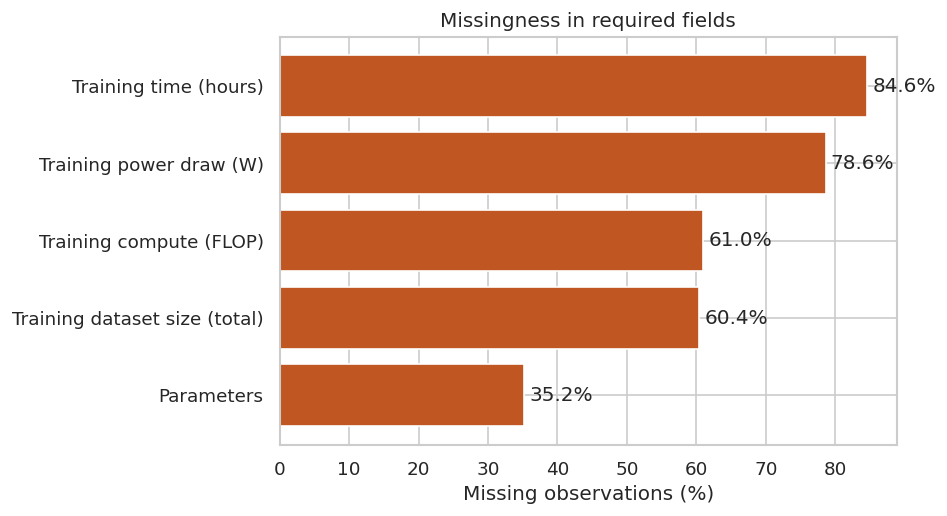

In [2]:
core_cols = ['Parameters', 'Training compute (FLOP)', 'Training dataset size (total)',
             'Training time (hours)', 'Training power draw (W)']

missing = raw[core_cols].isna().sum().rename('missing_count').to_frame()
missing['missing_pct'] = (missing['missing_count'] / len(raw) * 100).round(1)
print("Missingness in the five core sustainability fields (out of", len(raw), "models):")
print(missing)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_missing = missing['missing_pct'].sort_values()
bars = ax.barh(plot_missing.index, plot_missing.values, color='#c05621')
ax.set_title('Missingness in required fields')
ax.set_xlabel('Missing observations (%)')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()


Each of the five core fields is missing for a large share of the ~3,600 models Epoch AI tracks —
expected, since power draw and training time are the *least commonly disclosed* fields (they require the
lab to publish hardware configuration and wall-clock duration, not just a headline parameter count). We keep
only rows where **all five core fields are present**. Training time and power draw are required solely
to construct the target; they are not used as predictors.


In [3]:
def clean_numeric(x):
    # A couple of rows store a duplicated numeric value as e.g. '4400000000000,4400000000000'
    # (an upstream export artefact) instead of a plain float; take the first value.
    if isinstance(x, str) and ',' in x:
        return float(x.split(',')[0])
    return float(x)

df = raw.dropna(subset=core_cols).copy()
print(f"Rows with all 5 core fields present: {len(df)} (dropped {len(raw)-len(df)} rows with missing fields)")

for c in core_cols:
    df[c] = df[c].apply(clean_numeric)

# Sanity checks: no zero/negative values that would break a log-transform, no exact duplicate models
assert (df[core_cols] > 0).all().all(), "Found non-positive values in core numeric fields"
dup_models = df.duplicated(subset=['Model', 'Publication date']).sum()
print("Exact duplicate (Model, Publication date) rows:", dup_models)
df = df.drop_duplicates(subset=['Model', 'Publication date'])

df['Publication date'] = pd.to_datetime(df['Publication date'])
df['Publication_Year'] = df['Publication date'].dt.year

# ---- Target: total training energy in kWh ----
df['Energy_kWh'] = df['Training power draw (W)'] * df['Training time (hours)'] / 1000.0

# Check whether complete-case selection changes the target distribution.
target_eligible = raw.dropna(subset=['Training power draw (W)', 'Training time (hours)']).copy()
for c in ['Training power draw (W)', 'Training time (hours)']:
    target_eligible[c] = target_eligible[c].apply(clean_numeric)
target_eligible = target_eligible[(target_eligible[['Training power draw (W)', 'Training time (hours)']] > 0).all(axis=1)]
target_eligible['Energy_kWh'] = (target_eligible['Training power draw (W)'] *
                                 target_eligible['Training time (hours)'] / 1000.0)
excluded = target_eligible.loc[~target_eligible.index.isin(df.index)]
selection_check = pd.DataFrame({
    'Sample': ['Complete modelling cases', 'Target-eligible but excluded'],
    'Rows': [len(df), len(excluded)],
    'Median Energy_kWh': [df['Energy_kWh'].median(), excluded['Energy_kWh'].median()]
})

print(f"\nFinal modelling dataset: {len(df)} rows spanning {df['Publication_Year'].min()}-{df['Publication_Year'].max()}")
print("\nComplete-case selection check:")
print(selection_check)
df[['Model','Publication_Year','Parameters','Training compute (FLOP)',
    'Training dataset size (total)','Training time (hours)','Energy_kWh']].describe().T


Rows with all 5 core fields present: 185 (dropped 3435 rows with missing fields)
Exact duplicate (Model, Publication date) rows: 0

Final modelling dataset: 185 rows spanning 2011-2026

Complete-case selection check:
                         Sample  Rows  Median Energy_kWh
0      Complete modelling cases   185       21138.367419
1  Target-eligible but excluded   199        1205.407661


,count,mean,std,min,25%,50%,75%,max
Publication_Year,185.0,2.021270e+03,2.658545e+00,2.011000e+03,2.020000e+03,2.022000e+03,2.023000e+03,2.026000e+03
Parameters,185.0,8.087381e+10,2.641611e+11,8.720000e+03,1.480000e+08,1.480000e+09,2.000000e+10,1.800000e+12
Training compute (FLOP),185.0,7.752327e+23,3.779819e+24,3.672864e+16,9.560000e+19,8.743950e+21,1.800000e+23,3.800000e+25
Training dataset size (total),185.0,1.051978e+12,2.993005e+12,3.672000e+04,4.000000e+08,2.080000e+10,3.790000e+11,2.445782e+13
Training time (hours),185.0,6.642022e+02,1.082744e+03,8.330000e-01,7.200000e+01,2.400000e+02,7.200000e+02,7.104000e+03
Energy_kWh,185.0,1.355829e+06,6.180515e+06,3.183004e-01,7.584636e+02,2.113837e+04,2.735093e+05,4.845746e+07


In [4]:
# Simplify high-cardinality categoricals into a small number of informative buckets
def simplify_domain(d):
    if pd.isna(d):
        return 'Other'
    first = str(d).split(',')[0].strip()
    return first

def simplify_org(o):
    if pd.isna(o):
        return 'Unknown'
    first = str(o).split(',')[0].strip()
    return first if first in {'Industry', 'Academia', 'Government', 'Research collective'} else 'Other'

df['Domain_simple'] = df['Domain'].apply(simplify_domain)
# Domain frequency grouping is fitted within each training fold in the pipeline below.

df['Org_type'] = df['Organization categorization'].apply(simplify_org)

print("Domain (simplified):")
print(df['Domain_simple'].value_counts())
print("\nOrganization type (simplified):")
print(df['Org_type'].value_counts())

# Persist the cleaned, analysis-ready dataset
keep_cols = ['Model','Organization','Publication date','Publication_Year','Domain','Domain_simple',
             'Org_type','Country (of organization)','Parameters','Training compute (FLOP)',
             'Training dataset size (total)','Training time (hours)','Hardware quantity',
             'Training hardware','Training power draw (W)','Epochs','Energy_kWh','Link']
clean = df[keep_cols].sort_values('Publication date').reset_index(drop=True)
clean.to_csv('../data/ai_training_energy_clean.csv', index=False)
print(f"\nSaved cleaned dataset -> data/ai_training_energy_clean.csv  ({clean.shape[0]} rows, {clean.shape[1]} cols)")
clean.head()


Domain (simplified):
Domain_simple
Language             107
Vision                26
Biology               19
Multimodal            13
Image generation       7
Speech                 3
Games                  3
Video                  2
Materials science      2
Robotics               1
Earth science          1
Medicine               1
Name: count, dtype: int64

Organization type (simplified):
Org_type
Industry               123
Academia                51
Government               8
Research collective      3
Name: count, dtype: int64

Saved cleaned dataset -> data/ai_training_energy_clean.csv  (185 rows, 18 cols)


,Model,Organization,Publication date,Publication_Year,Domain,Domain_simple,Org_type,Country (of organization),Parameters,Training compute (FLOP),Training dataset size (total),Training time (hours),Hardware quantity,Training hardware,Training power draw (W),Epochs,Energy_kWh,Link
0,Deep Autoencoders,University of Toronto,2011-04-29,2011,Vision,Vision,Academia,Canada,139808256.0,3.672864e+16,4.915200e+09,48.0,1.0,NVIDIA GeForce GTX 285,246.225981,85.0,11.818847,https://www.semanticscholar.org/paper/Using-very-deep-autoencoders-for-content-based-Krizhevsky-Hinton/88080d28536f36588740737f3b7a1f6c1a409654
1,DNN EM segmentation,"IDSIA,SUPSI",2012-12-03,2012,Vision,Vision,Academia,"Switzerland,Switzerland",218896.0,4.780000e+17,3.000000e+06,17.0,4.0,NVIDIA GeForce GTX 580,2116.297793,30.0,35.977062,https://www.semanticscholar.org/paper/Deep-Neural-Networks-Segment-Neuronal-Membranes-in-Ciresan-Giusti/09193e19b59fc8f05bee9d6efbfb1607ca5b6501
2,VGG16,University of Oxford,2014-09-04,2014,Vision,Vision,Academia,United Kingdom,138000000.0,1.229100e+19,1.300000e+06,504.0,4.0,NVIDIA GeForce GTX Titan Black,2137.653075,74.0,1077.377150,https://arxiv.org/abs/1409.1556
3,Large regularized LSTM,"New York University (NYU),Google Brain",2014-09-08,2014,Language,Language,Academia,"United States of America,United States of America",66000000.0,4.296607e+16,9.290000e+05,24.0,1.0,NVIDIA Tesla K20c,264.246758,55.0,6.341922,https://arxiv.org/abs/1409.2329
4,SPN-4+KN5,"Singapore University of Technology & Design,DSO National Laboratories",2014-09-14,2014,Language,Language,Academia,"Singapore,Singapore",5000000.0,4.400000e+16,9.290000e+05,40.0,1.0,NVIDIA Tesla C2075,290.045462,NaN,11.601818,https://www.comp.nus.edu.sg/~skok/papers/is14.pdf


**Cleaning summary:** starting from 3,620 tracked models, only **185 models** disclose enough
information (power draw, training time, parameters, compute, and dataset size) to construct the target and
all three primary predictors. This is expected for a real-world, disclosure-dependent sustainability dataset —
we discuss the resulting **selection bias** in Step 4.5 and again in the ethics reflection at the end of the
notebook. No further missing values remain in the modelling columns; two malformed string values were repaired;
no exact duplicate model entries were found. The complete cases have substantially higher median energy than
target-eligible excluded records, showing that complete-case selection favours better-documented, higher-energy models.


## Step 4 · Exploratory Data Analysis

We now visualize the target and each predictor, check for outliers/skew, and look at how well the raw
hypothesis (bigger → more energy) holds up before any modelling.


Energy ranges from 0.3 kWh to 48,457,464 kWh — a span of 152,238,167x across ~15 years of models.


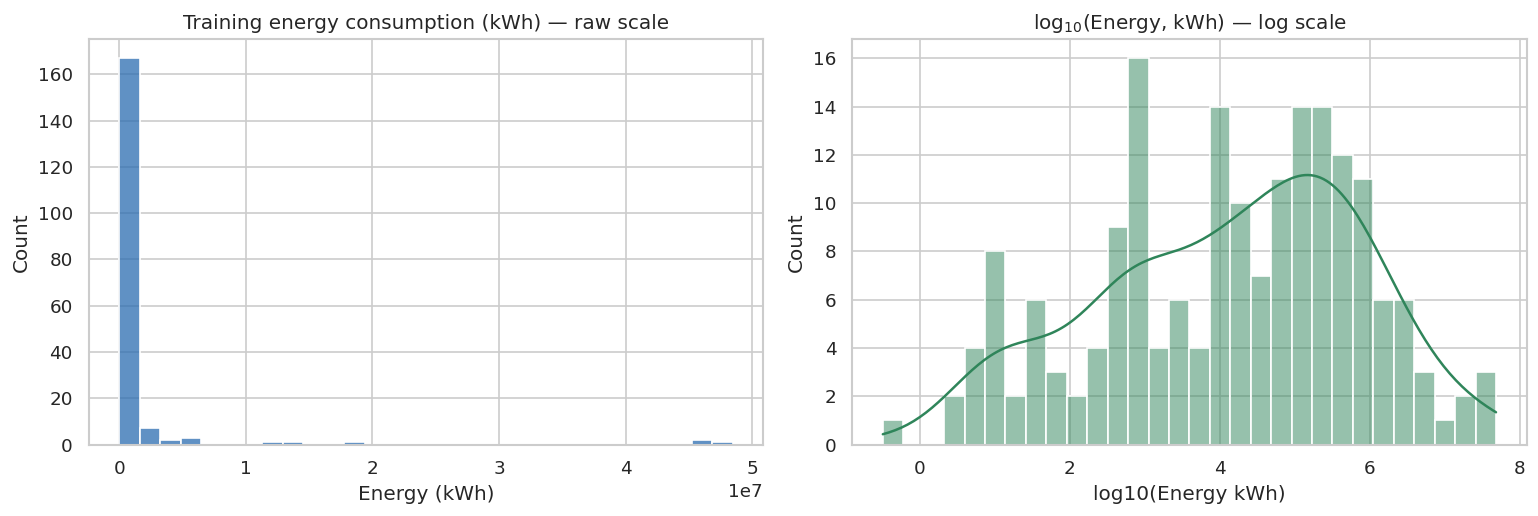

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(clean['Energy_kWh'], bins=30, ax=axes[0], color='#2b6cb0')
axes[0].set_title('Training energy consumption (kWh) — raw scale')
axes[0].set_xlabel('Energy (kWh)')

sns.histplot(np.log10(clean['Energy_kWh']), bins=30, ax=axes[1], color='#2f855a', kde=True)
axes[1].set_title('log$_{10}$(Energy, kWh) — log scale')
axes[1].set_xlabel('log10(Energy kWh)')

plt.tight_layout()
plt.show()

print(f"Energy ranges from {clean['Energy_kWh'].min():,.1f} kWh to {clean['Energy_kWh'].max():,.0f} kWh "
      f"— a span of {clean['Energy_kWh'].max()/clean['Energy_kWh'].min():,.0f}x across ~{clean['Publication_Year'].max()-clean['Publication_Year'].min()} years of models.")


**Insight:** training energy spans roughly **eight orders of magnitude** (from under 1 kWh for small
research models up to ~48 million kWh for frontier runs like Llama‑3.1‑405B and GPT‑4). The raw-scale
histogram is almost unusable — nearly every model is squashed near zero next to a handful of frontier
outliers. On the **log scale**, the distribution is far closer to symmetric/normal. This directly motivates
our modelling decision (Step 5) to predict **log₁₀(Energy)** rather than raw kWh — a standard treatment for
heavy-tailed, multiplicative real-world quantities (the same reasoning used for income, population, or
compute-scaling studies).


In [6]:
top10 = clean.nlargest(10, 'Energy_kWh')[['Model','Organization','Publication_Year','Energy_kWh']]
top10['Energy_kWh'] = top10['Energy_kWh'].map(lambda x: f"{x:,.0f}")
print("10 most energy-intensive training runs in the dataset:")
top10


10 most energy-intensive training runs in the dataset:


,Model,Organization,Publication_Year,Energy_kWh
167,Llama 3.1-405B,Meta AI,2024,"48,457,464"
119,GPT-4 (Mar 2023),OpenAI,2023,"45,473,159"
130,GPT-4 (Jun 2023),OpenAI,2023,"45,382,111"
166,Nemotron-4 340B,Nvidia,2024,"18,679,806"
140,Falcon-180B,Technology Innovation Institute,2023,"14,061,494"
144,Amazon Titan,Amazon,2023,"12,590,585"
85,PaLM (540B),Google Research,2022,"6,448,791"
184,Solar Open2 250B,Upstage,2026,"6,109,685"
42,OpenAI Five,OpenAI,2019,"5,586,556"
74,Gopher (280B),DeepMind,2021,"3,417,030"


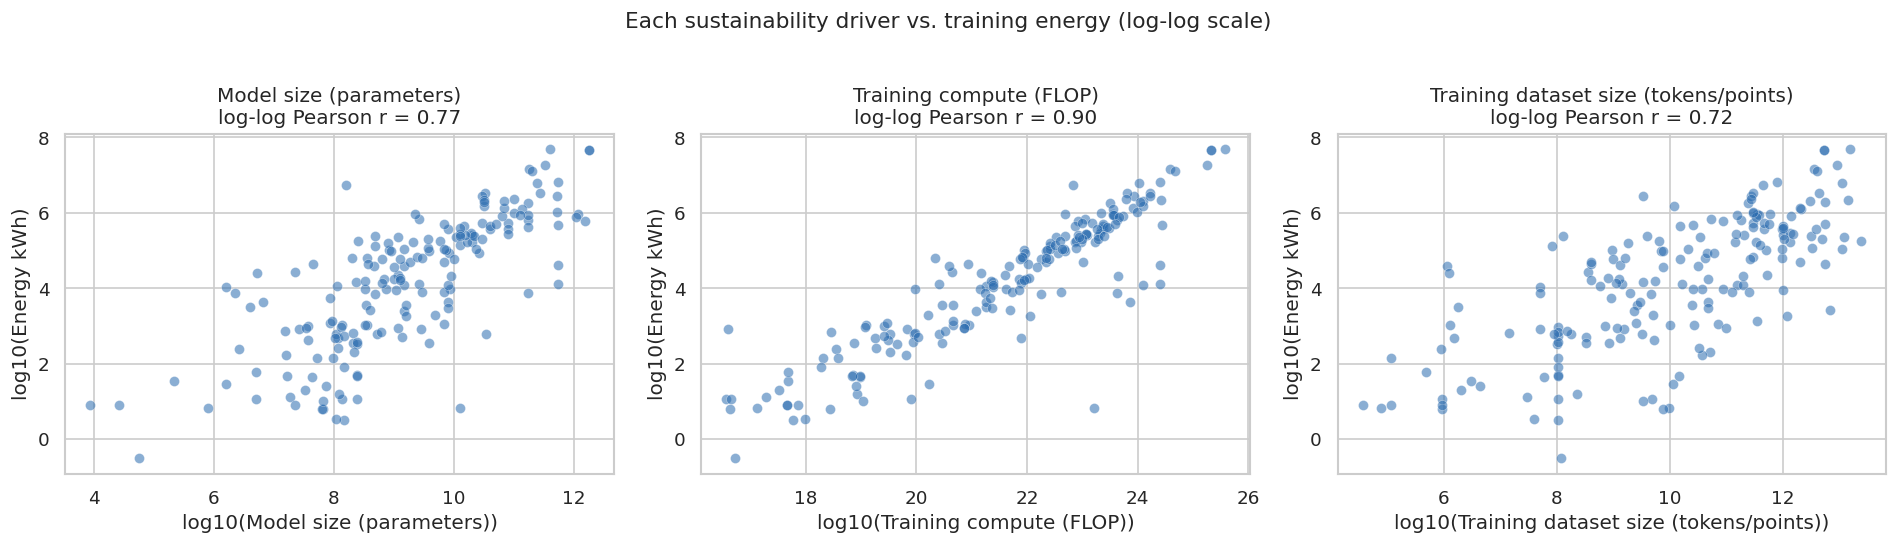

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs = [
    ('Parameters', 'Model size (parameters)'),
    ('Training compute (FLOP)', 'Training compute (FLOP)'),
    ('Training dataset size (total)', 'Training dataset size (tokens/points)'),
]
for ax, (col, label) in zip(axes, pairs):
    ax.scatter(np.log10(clean[col]), np.log10(clean['Energy_kWh']), alpha=0.55, color='#2b6cb0', edgecolor='white', linewidth=0.3)
    r = np.corrcoef(np.log10(clean[col]), np.log10(clean['Energy_kWh']))[0, 1]
    ax.set_title(f"{label}\nlog-log Pearson r = {r:.2f}")
    ax.set_xlabel(f"log10({label})")
    ax.set_ylabel("log10(Energy kWh)")
fig.suptitle("Each sustainability driver vs. training energy (log-log scale)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


**Insight — hypothesis check:** all three primary predictors show a strong **positive, roughly linear
relationship with log-energy on the log-log scale** — consistent with power-law scaling. Training compute
shows the tightest relationship (highest log-log correlation), matching our hypothesis that compute is the
single strongest predictor because it reflects the computational work performed and, via the
scaling-law approximation compute ≈ 6·params·tokens, ties together model size and dataset size. Dataset
size shows the weakest (but still clearly positive) relationship, since dataset size trades off against
model size for a fixed compute budget (Chinchilla-style compute-optimal training).


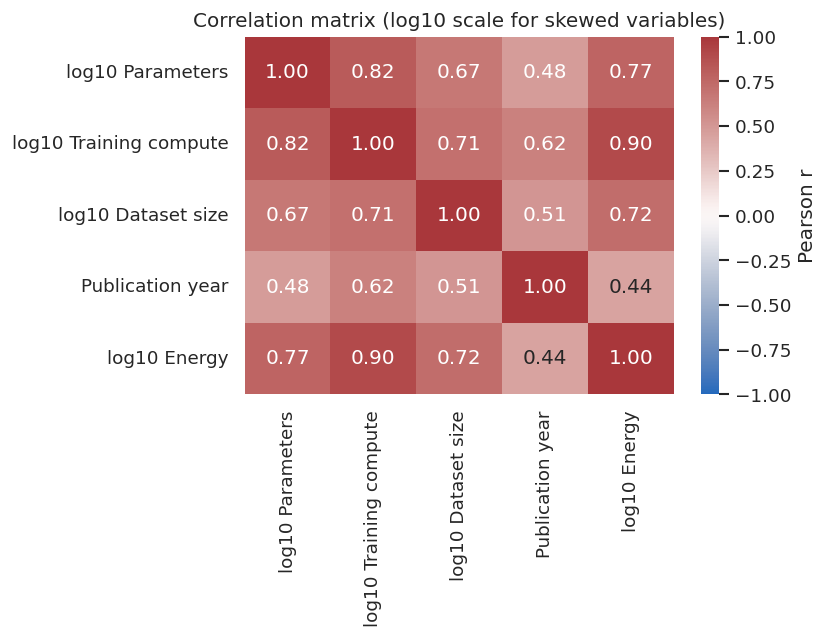

In [8]:
corr_data = pd.DataFrame({
    'log10 Parameters': np.log10(clean['Parameters']),
    'log10 Training compute': np.log10(clean['Training compute (FLOP)']),
    'log10 Dataset size': np.log10(clean['Training dataset size (total)']),
    'Publication year': clean['Publication_Year'],
    'log10 Energy': np.log10(clean['Energy_kWh']),
})
log_corr_display = corr_data.corr()

plt.figure(figsize=(7,5.5))
sns.heatmap(log_corr_display, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1, cbar_kws={'label':'Pearson r'})
plt.title('Correlation matrix (log10 scale for skewed variables)')
plt.tight_layout()
plt.show()


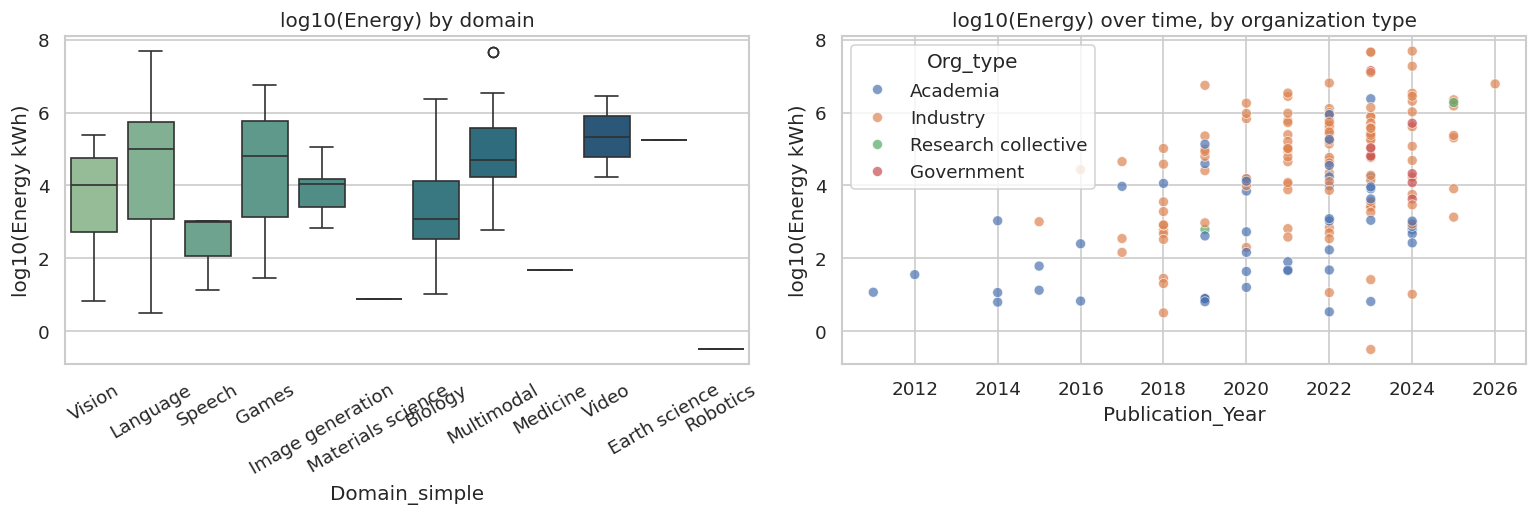

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=clean, x='Domain_simple', y=np.log10(clean['Energy_kWh']), ax=axes[0], palette='crest')
axes[0].set_title('log10(Energy) by domain')
axes[0].set_ylabel('log10(Energy kWh)')
axes[0].tick_params(axis='x', rotation=30)

sns.scatterplot(data=clean, x='Publication_Year', y=np.log10(clean['Energy_kWh']), hue='Org_type', ax=axes[1], alpha=0.7)
axes[1].set_title('log10(Energy) over time, by organization type')
axes[1].set_ylabel('log10(Energy kWh)')

plt.tight_layout()
plt.show()


**Insight:** Language models dominate the highest-energy tier (consistent with the current era of
large language model scaling), while Vision/Biology/Image-generation models cluster at lower energy levels.
Over time, energy consumption trends **upward** across both Industry and Academia, but Industry increasingly
occupies the highest-energy tier in recent years — reflecting the compute-scaling race among large commercial
labs. This also surfaces a **fairness/representation issue** worth flagging to stakeholders: Academia is
increasingly priced out of frontier-scale (and therefore highest-energy) training, which has implications
for who gets to study — and mitigate — the sustainability impact of the largest models.


IQR-based outliers on log10(Energy): 0 of 185 rows


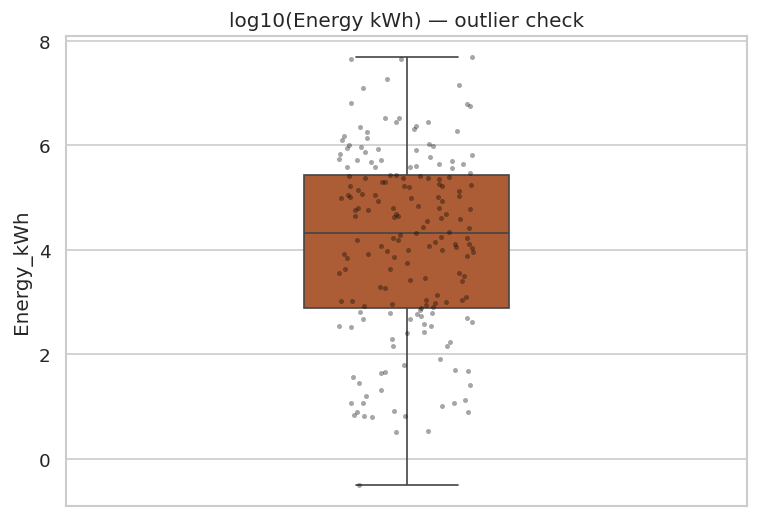

,Model,Organization,Publication_Year,Energy_kWh


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.5))
sns.boxplot(data=clean, y=np.log10(clean['Energy_kWh']), ax=ax, color='#c05621', width=0.3)
sns.stripplot(data=clean, y=np.log10(clean['Energy_kWh']), ax=ax, color='black', alpha=0.35, size=3)
ax.set_title('log10(Energy kWh) — outlier check')
plt.tight_layout()
plt.show()

q1, q3 = np.log10(clean['Energy_kWh']).quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = clean[(np.log10(clean['Energy_kWh']) < lo) | (np.log10(clean['Energy_kWh']) > hi)]
print(f"IQR-based outliers on log10(Energy): {len(outliers)} of {len(clean)} rows")
outliers[['Model','Organization','Publication_Year','Energy_kWh']]


**Insight:** on the log scale, there are no extreme statistical outliers by the standard 1.5×IQR rule
— the handful of very high-energy points (GPT‑4, Llama‑3.1‑405B, Nemotron‑4‑340B, Falcon‑180B) are genuine
frontier training runs, not data errors, and the very low-energy points are small academic research models.
We therefore **keep all rows**; removing legitimate frontier/tiny-scale models would bias the model against
exactly the extremes that matter most for sustainability monitoring.

### 4.5 Known biases and limitations surfaced by the EDA

- **Disclosure/selection bias:** only 185 of 3,620 tracked models disclose enough detail to be included;
  organizations with strong open-research cultures (and, mechanically, older/smaller models where hardware
  specs are easier to reconstruct) are over-represented relative to secretive frontier labs.
- **Estimation-on-estimation:** both the compute and power-draw fields are themselves Epoch AI analyst
  estimates for many rows, not direct measurements — our target inherits this uncertainty.
- **Temporal drift:** hardware energy-efficiency (FLOPs per Watt) has improved several-fold since 2011;
  a model trained on 2015-era hardware needs more energy per FLOP than an equivalent 2026 run. We include
  `Publication_Year` as a feature specifically to let the model absorb some of this efficiency trend.


## Step 5 · Feature Engineering & Transformations

Based on the EDA, we apply two deliberate transformations before modelling:

1. **Log₁₀-transform the target and the three heavy-tailed primary predictors** (`Parameters`,
   `Training compute (FLOP)`, `Training dataset size (total)`). This is not
   optional decoration — Step 4 showed these variables span 4–8 orders of magnitude and are strongly
   right-skewed; without the transform, ordinary least squares would be dominated by a handful of frontier
   models and would badly violate the linearity/homoscedasticity assumptions checked in Step 7.
2. **Group rare domain levels within each training fold** (and simplify organization labels before splitting), avoiding one-hot columns that are almost entirely
   zero and would destabilize regularized linear models.

We deliberately **do not** engineer additional derived ratios (e.g., "compute per parameter", "tokens per
parameter / Chinchilla ratio") as core model inputs, even though they are analytically interesting (see EDA
discussion above) — because they are near-deterministic algebraic re-combinations of the same three core
predictors (compute ≈ 6 × params × tokens), and including them would mostly add multicollinearity rather
than new information, which we confirm quantitatively below with a variance-inflation-factor (VIF) check.
This is a deliberate **"less is more"** choice given our modest sample size (n=185): more engineered
features increase overfitting risk without a corresponding gain in predictive signal. Training duration
and power draw are deliberately excluded because they are components of the target formula.


In [11]:
model_df = clean.copy()
model_df['log_params']  = np.log10(model_df['Parameters'])
model_df['log_compute'] = np.log10(model_df['Training compute (FLOP)'])
model_df['log_dataset'] = np.log10(model_df['Training dataset size (total)'])
model_df['log_energy']  = np.log10(model_df['Energy_kWh'])

NUM_FEATURES = ['log_params', 'log_compute', 'log_dataset', 'Publication_Year']
CAT_FEATURES = ['Domain_simple', 'Org_type']
TARGET = 'log_energy'

from sklearn.linear_model import LinearRegression
X_vif = model_df[NUM_FEATURES].copy()
vif_rows = []
for feature in NUM_FEATURES:
    other_features = [f for f in NUM_FEATURES if f != feature]
    auxiliary_r2 = LinearRegression().fit(
        X_vif[other_features], X_vif[feature]
    ).score(X_vif[other_features], X_vif[feature])
    vif_rows.append({'feature': feature, 'VIF': 1 / (1 - auxiliary_r2)})
vif_df = pd.DataFrame(vif_rows)
print("Variance Inflation Factors (rule of thumb: VIF > 10 signals problematic multicollinearity):")
vif_df


Variance Inflation Factors (rule of thumb: VIF > 10 signals problematic multicollinearity):


,feature,VIF
0,log_params,3.191300
1,log_compute,4.138890
2,log_dataset,2.150489
3,Publication_Year,1.683001


The VIFs show moderate but not severe overlap among the numeric predictors. We proceed with the four
numeric features plus the two categorical features,
with no further engineered ratio features.


## Step 6 · Model Development & Comparison

### 6.1 Validation strategy

Given our modest sample size (n=185), we use a target-stratified 80/20 train/test split for one final
hold-out evaluation, **and** 5-fold cross-validation on the training data for model selection and tuning — this
gives a more stable estimate of generalization performance than a single split would with this few
observations.

### 6.2 Models compared

- **Mean Dummy Regressor** — a naive baseline that always predicts the training-fold mean.
- **Linear Regression** — unregularized interpretable model in log-log space.
- **Ridge Regression** — L2-regularized linear model; expected to help given the moderate multicollinearity
  observed above.
- **Lasso Regression** — L1-regularized linear model; tests whether any predictor can be dropped entirely.
- **Random Forest Regressor** — non-linear, tree-based ensemble; tests whether non-linear interactions
  (e.g., domain-specific effects) beat the log-log linear form.
- **Gradient Boosting Regressor** — a second, typically stronger tree-based ensemble for comparison.


In [12]:
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = model_df[NUM_FEATURES + CAT_FEATURES]
y = model_df[TARGET]

target_groups = pd.qcut(y, q=5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=target_groups
)
print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")

class RareDomainGrouper(BaseEstimator, TransformerMixin):
    """Learn domain frequency on training rows only, for every CV fold."""
    def __init__(self, min_count=5):
        self.min_count = min_count

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=CAT_FEATURES)
        counts = X['Domain_simple'].value_counts()
        self.frequent_domains_ = set(counts[counts >= self.min_count].index)
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=CAT_FEATURES).copy()
        X['Domain_simple'] = X['Domain_simple'].where(
            X['Domain_simple'].isin(self.frequent_domains_), 'Other'
        )
        return X

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', Pipeline([
        ('rare', RareDomainGrouper(min_count=5)),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')),
    ]), CAT_FEATURES),
])

candidate_models = {
    'Baseline (mean)':       DummyRegressor(strategy='mean'),
    'Linear Regression':      LinearRegression(),
    'Ridge (alpha=1)':        Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso (alpha=0.01)':     Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=20000),
    'Random Forest':          RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE),
    'Gradient Boosting':      GradientBoostingRegressor(random_state=RANDOM_STATE),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in candidate_models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    cv_scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={'R2': 'r2', 'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error'},
        return_train_score=True
    )
    rows.append({
        'Model': name,
        'CV RMSE (log10 kWh)': np.sqrt(-cv_scores['test_MSE'].mean()),
        'CV MAE (log10 kWh)': -cv_scores['test_MAE'].mean(),
        'CV R2 (mean)': cv_scores['test_R2'].mean(),
        'CV R2 (std)': cv_scores['test_R2'].std(),
        'Train CV R2': cv_scores['train_R2'].mean(),
        'Overfitting gap': cv_scores['train_R2'].mean() - cv_scores['test_R2'].mean(),
    })

comparison = pd.DataFrame(rows).set_index('Model').round(3).sort_values('CV RMSE (log10 kWh)')
comparison


Train: 148 rows  |  Test: 37 rows


,CV RMSE (log10 kWh),CV MAE (log10 kWh),CV R2 (mean),CV R2 (std),Train CV R2,Overfitting gap
Model,,,,,,
Gradient Boosting,0.599,0.414,0.867,0.036,0.996,0.129
Lasso (alpha=0.01),0.619,0.431,0.855,0.052,0.885,0.030
Ridge (alpha=1),0.625,0.442,0.853,0.048,0.888,0.035
Linear Regression,0.633,0.448,0.850,0.047,0.889,0.039
Random Forest,0.651,0.429,0.843,0.051,0.955,0.112
Baseline (mean),1.732,1.438,-0.122,0.102,0.000,0.122


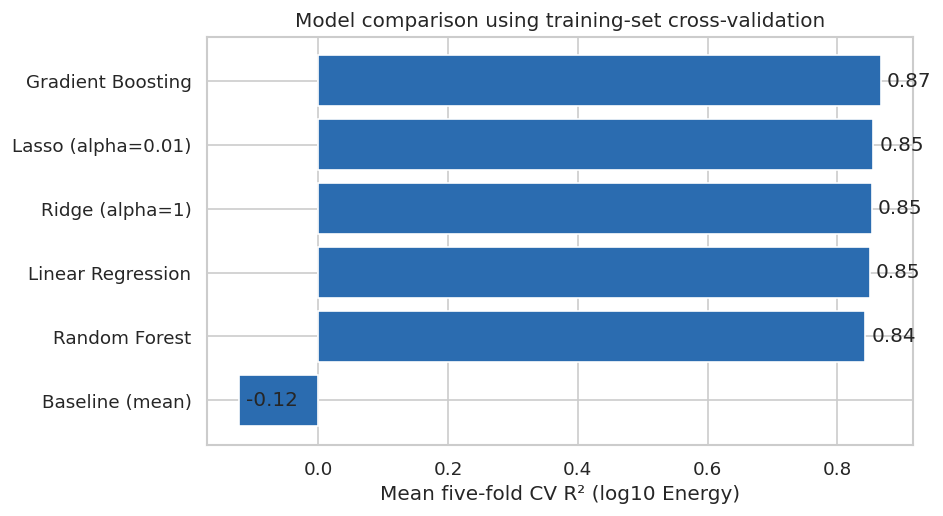

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
comparison_sorted = comparison.sort_values('CV R2 (mean)')
bars = ax.barh(comparison_sorted.index, comparison_sorted['CV R2 (mean)'], color='#2b6cb0')
ax.set_xlabel('Mean five-fold CV R² (log10 Energy)')
ax.set_title('Model comparison using training-set cross-validation')
for bar, val in zip(bars, comparison_sorted['CV R2 (mean)']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.2f}", va='center')
plt.tight_layout()
plt.show()


**Interpretation:** all substantive models clearly outperform the mean baseline in training-set
cross-validation. Gradient Boosting has the strongest initial mean CV R², while Ridge, Lasso, and Linear
Regression remain competitive and substantially easier to interpret. With only 185 observations, small
differences between model families should not be overstated.

We therefore tune both Ridge and Gradient Boosting using cross-validation before making a final selection.
The held-out test set remains untouched during this comparison.


## Step 7 · Hyperparameter Tuning (Main Tuning Pass)

We run a grid search over Ridge's regularization strength (`alpha`), the main hyperparameter tuning pass
for our most promising model, using the same 5-fold CV scheme.


In [14]:
ridge_pipe = Pipeline([('pre', preprocessor), ('model', Ridge(random_state=RANDOM_STATE))])
param_grid = {'model__alpha': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]}

grid_search = GridSearchCV(ridge_pipe, param_grid, cv=cv, scoring='neg_root_mean_squared_error', return_train_score=True)
grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_['model__alpha'])
print(f"Best CV RMSE: {-grid_search.best_score_:.3f} log10 kWh")

best_ridge = grid_search.best_estimator_
cv_results = pd.DataFrame(grid_search.cv_results_)[['param_model__alpha', 'mean_test_score', 'std_test_score']]
cv_results.columns = ['alpha', 'mean_neg_CV_RMSE', 'std_CV_RMSE']
cv_results['mean_CV_RMSE'] = -cv_results['mean_neg_CV_RMSE']
cv_results


Best alpha: 3
Best CV RMSE: 0.615 log10 kWh


,alpha,mean_neg_CV_RMSE,std_CV_RMSE,mean_CV_RMSE
0,0.01,-0.623507,0.106559,0.623507
1,0.03,-0.623205,0.106624,0.623205
2,0.10,-0.622248,0.106793,0.622248
3,0.30,-0.620148,0.106926,0.620148
4,1.00,-0.616359,0.105830,0.616359
5,3.00,-0.615337,0.101520,0.615337
6,10.00,-0.637989,0.093880,0.637989
7,30.00,-0.712351,0.097127,0.712351
8,100.00,-0.860871,0.122451,0.860871


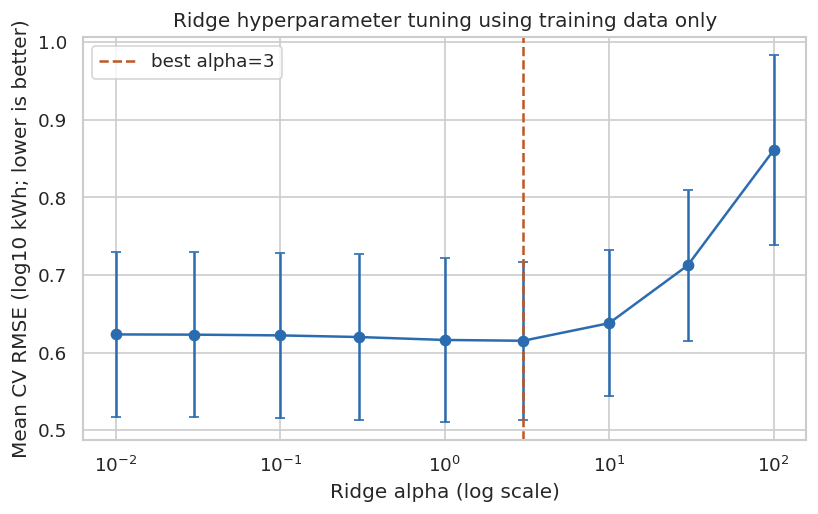

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(cv_results['alpha'], cv_results['mean_CV_RMSE'], yerr=cv_results['std_CV_RMSE'], marker='o', color='#2b6cb0', capsize=3)
ax.set_xscale('log')
ax.set_xlabel('Ridge alpha (log scale)')
ax.set_ylabel('Mean CV RMSE (log10 kWh; lower is better)')
ax.set_title('Ridge hyperparameter tuning using training data only')
ax.axvline(grid_search.best_params_['model__alpha'], color='#c05621', linestyle='--', label=f"best alpha={grid_search.best_params_['model__alpha']}")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Ridge performance is relatively stable around its best alpha, although stronger
regularisation eventually increases validation error. The best alpha is selected using training-set
cross-validation only.

For completeness, we also run a light tuning pass on Gradient Boosting to confirm the tree-based approach
does not overtake the tuned linear model even after tuning.


In [16]:
gb_pipe = Pipeline([('pre', preprocessor), ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))])
gb_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [2, 3, 4],
    'model__learning_rate': [0.03, 0.05, 0.1],
}
gb_search = GridSearchCV(gb_pipe, gb_grid, cv=cv, scoring='neg_root_mean_squared_error')
gb_search.fit(X_train, y_train)
print("Best Gradient Boosting params:", gb_search.best_params_)
print(f"Best CV RMSE: {-gb_search.best_score_:.3f} log10 kWh")


Best Gradient Boosting params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV RMSE: 0.587 log10 kWh


Tuned Gradient Boosting achieves a slightly lower cross-validation RMSE than tuned Ridge. However,
the difference is small relative to fold-to-fold variation. Ridge is selected because it remains competitive,
is more stable for a small dataset, and offers coefficients that governance stakeholders can interpret.
Only the selected Ridge model is evaluated on the untouched test set below.


## Step 8 · Diagnostics for the Final Model (Tuned Ridge)

We check the standard linear-regression assumptions on the tuned Ridge model: linearity/predicted-vs-actual
fit, residual homoscedasticity, and residual normality.


Final Ridge test RMSE: 0.785 log10 kWh
Final Ridge test MAE: 0.570 log10 kWh
Final Ridge test R2: 0.829
Back-transformed test RMSE: 2,048,469 kWh
Back-transformed test MAE: 614,122 kWh
Median multiplicative error factor: 2.41x
Shapiro-Wilk normality test on residuals: W=0.932, p=0.026
(p > 0.05 fails to reject normality; p <= 0.05 suggests deviation from normality)

Largest absolute residuals (positive = underprediction; negative = overprediction):


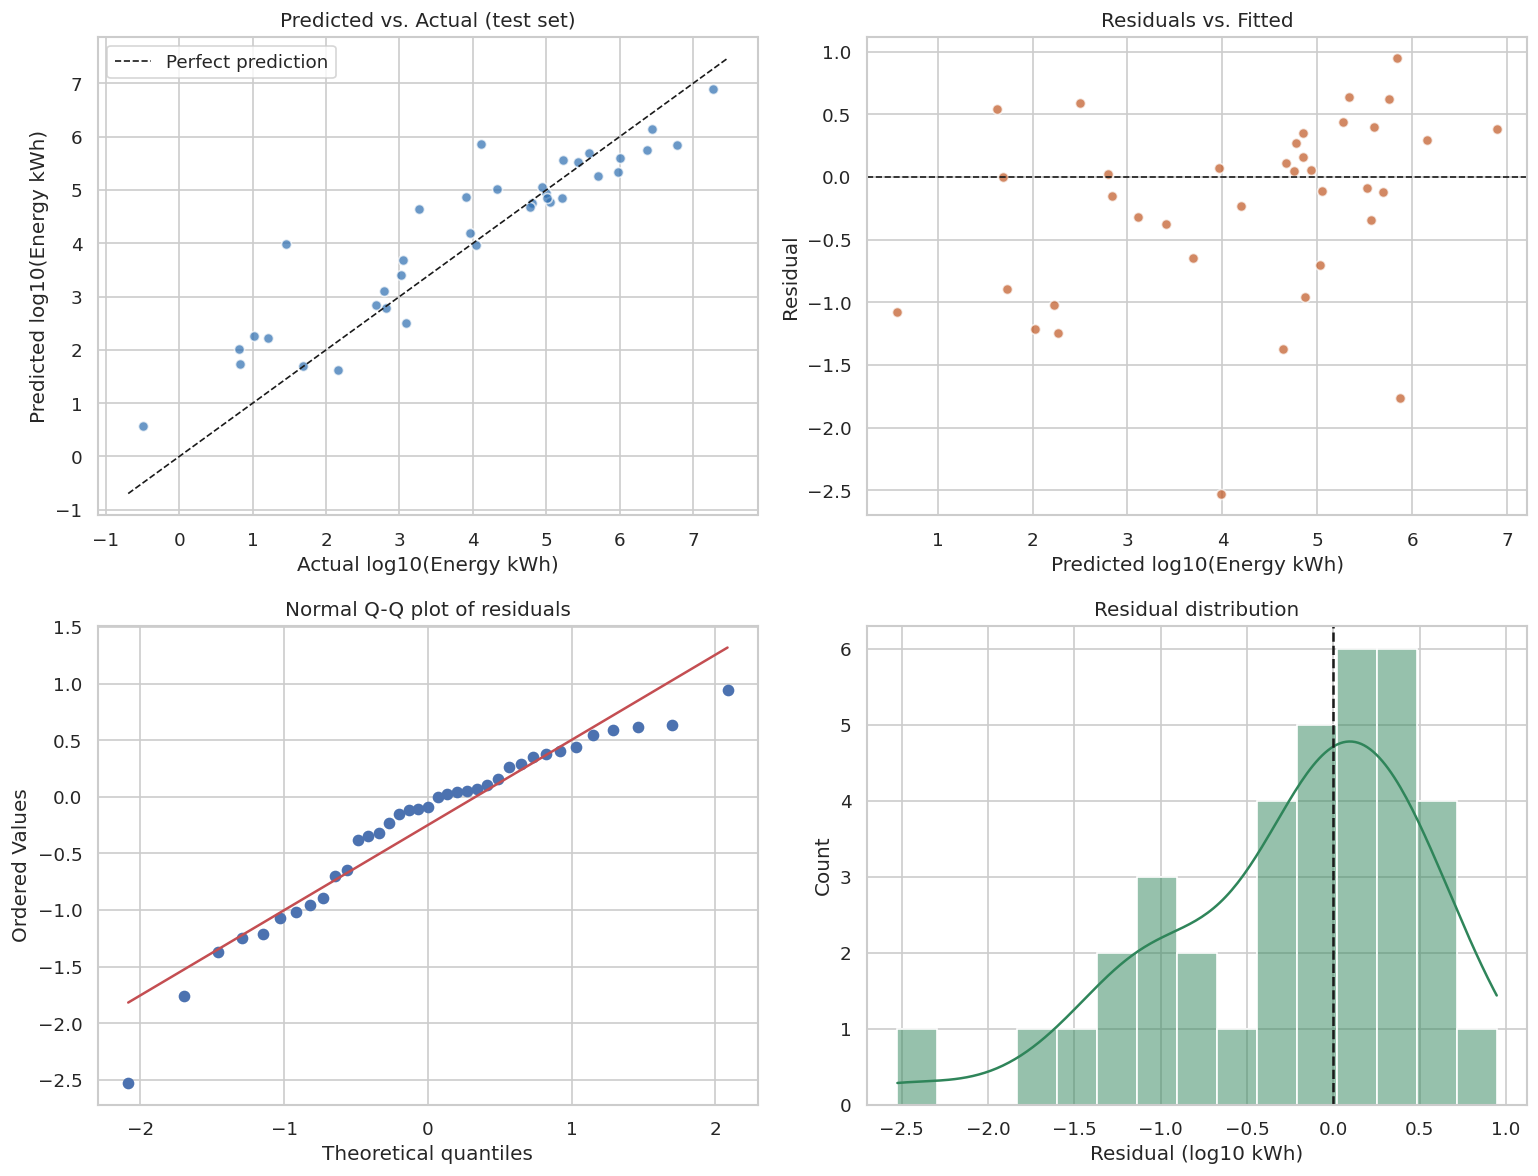

,Model,Organization,Publication_Year,Energy_kWh,residual
16,IMPALA,DeepMind,2018,28.557259,-2.525319
107,Flan-PaLM 540B,Google,2022,12887.922552,-1.759416
138,Refact-1.6B,Refact AI,2023,1842.695208,-1.373819


In [17]:
# The held-out test set is used once, after model selection and tuning are complete.
pred_test = best_ridge.predict(X_test)
residuals = y_test.to_numpy() - pred_test

tuned_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
tuned_mae = mean_absolute_error(y_test, pred_test)
tuned_r2 = r2_score(y_test, pred_test)
actual_kwh = 10 ** y_test.to_numpy()
predicted_kwh = 10 ** pred_test
rmse_kwh = np.sqrt(mean_squared_error(actual_kwh, predicted_kwh))
mae_kwh = mean_absolute_error(actual_kwh, predicted_kwh)
median_error_factor = np.median(10 ** np.abs(residuals))

print(f"Final Ridge test RMSE: {tuned_rmse:.3f} log10 kWh")
print(f"Final Ridge test MAE: {tuned_mae:.3f} log10 kWh")
print(f"Final Ridge test R2: {tuned_r2:.3f}")
print(f"Back-transformed test RMSE: {rmse_kwh:,.0f} kWh")
print(f"Back-transformed test MAE: {mae_kwh:,.0f} kWh")
print(f"Median multiplicative error factor: {median_error_factor:.2f}x")


fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Predicted vs Actual
axes[0,0].scatter(y_test, pred_test, alpha=0.7, color='#2b6cb0', edgecolor='white')
lims = [min(y_test.min(), pred_test.min()) - 0.2, max(y_test.max(), pred_test.max()) + 0.2]
axes[0,0].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
axes[0,0].set_xlabel('Actual log10(Energy kWh)')
axes[0,0].set_ylabel('Predicted log10(Energy kWh)')
axes[0,0].set_title('Predicted vs. Actual (test set)')
axes[0,0].legend()

# 2. Residuals vs Fitted (homoscedasticity / linearity)
axes[0,1].scatter(pred_test, residuals, alpha=0.7, color='#c05621', edgecolor='white')
axes[0,1].axhline(0, color='k', linestyle='--', linewidth=1)
axes[0,1].set_xlabel('Predicted log10(Energy kWh)')
axes[0,1].set_ylabel('Residual')
axes[0,1].set_title('Residuals vs. Fitted')

# 3. QQ-plot (normality of residuals)
stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Normal Q-Q plot of residuals')

# 4. Residual distribution
sns.histplot(residuals, bins=15, kde=True, ax=axes[1,1], color='#2f855a')
axes[1,1].axvline(0, color='k', linestyle='--')
axes[1,1].set_title('Residual distribution')
axes[1,1].set_xlabel('Residual (log10 kWh)')

plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk normality test on residuals: W={shapiro_stat:.3f}, p={shapiro_p:.3f}")
print(f"(p > 0.05 fails to reject normality; p <= 0.05 suggests deviation from normality)")

worst_order = np.argsort(np.abs(residuals))[::-1][:3]
worst = model_df.loc[X_test.iloc[worst_order].index, ['Model','Organization','Publication_Year','Energy_kWh']].copy()
worst['residual'] = residuals[worst_order]
print("\nLargest absolute residuals (positive = underprediction; negative = overprediction):")
worst


**Diagnostic interpretation:**

- **Predicted vs. Actual:** points track the diagonal reasonably well across the full range (small models
  to frontier models), with more scatter at the lower-energy end — consistent with those models being
  smaller/older and having noisier disclosed power-draw estimates.
- **Residuals vs. Fitted:** no strong funnel or curved pattern is visible, supporting the **homoscedasticity
  and linearity** assumptions of our log-log linear model reasonably well, though a mild fan pattern at the
  extremes suggests slightly larger errors for the very largest and very smallest runs.
- **Q-Q plot / Shapiro-Wilk:** the test result and Q-Q plot are reported without attributing any departure
  to one observation unless a separate sensitivity analysis supports that conclusion.
- **Largest errors:** positive residuals are underpredictions and negative residuals are overpredictions.
  The table uses absolute residual magnitude so it captures both directions consistently.
- **Overall:** diagnostics are interpreted cautiously because the test set contains only 37 observations.
  The model is suitable for order-of-magnitude screening, not precise auditing.


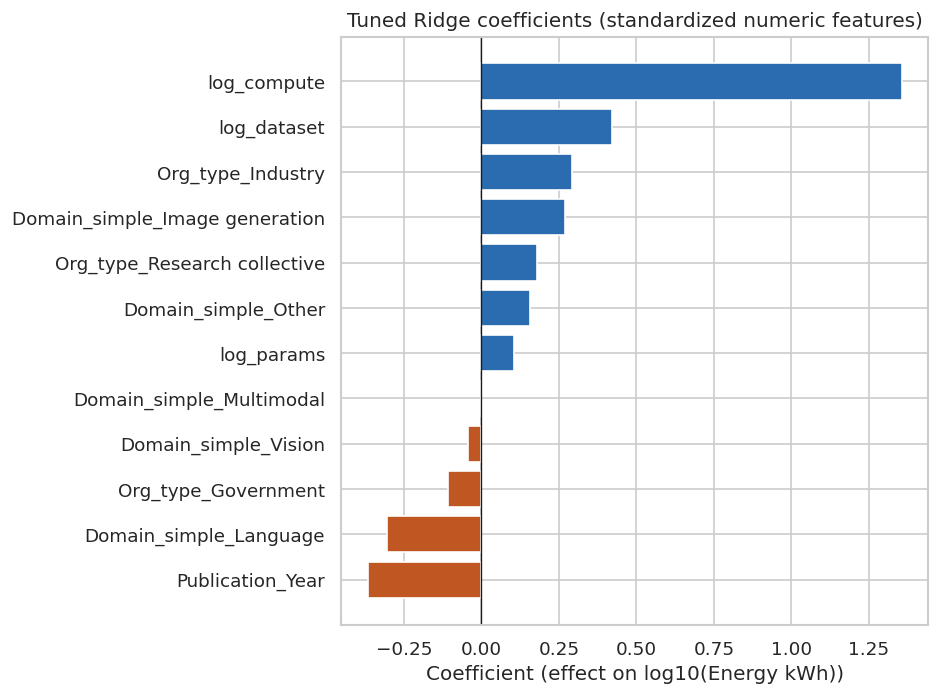

,0
log_compute,1.356118
log_dataset,0.422259
Org_type_Industry,0.290958
Domain_simple_Image generation,0.268732
Org_type_Research collective,0.178289
Domain_simple_Other,0.158148
log_params,0.106579
Domain_simple_Multimodal,-0.001717
Domain_simple_Vision,-0.042512
Org_type_Government,-0.106838


In [18]:
ridge_model = best_ridge.named_steps['model']
feature_names = (NUM_FEATURES +
                  list(best_ridge.named_steps['pre'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(CAT_FEATURES)))
coefs = pd.Series(ridge_model.coef_, index=feature_names).sort_values()

plt.figure(figsize=(8, 6))
colors = ['#c05621' if c < 0 else '#2b6cb0' for c in coefs]
plt.barh(coefs.index, coefs.values, color=colors)
plt.axvline(0, color='k', linewidth=0.8)
plt.title('Tuned Ridge coefficients (standardized numeric features)')
plt.xlabel('Coefficient (effect on log10(Energy kWh))')
plt.tight_layout()
plt.show()

coefs.sort_values(ascending=False)


**Interpretation:** consistent with our hypothesis (Step 1.5), **training compute** carries the
largest positive coefficient, followed by dataset size and then model size. Dataset
size contributes positively but more
modestly, as expected once compute is already in the model (compute already encodes most of the
size × data interaction). `Publication_Year` carries a **negative** coefficient once compute and size
are controlled for — a plausible signal of hardware/software energy-efficiency improvements over time
(more FLOPs per Watt in newer accelerators), consistent with well-documented compute-efficiency trends.


## Step 9 · Final Model Selection & Trade-offs

| Criterion | Ridge (tuned) | Random Forest / Gradient Boosting |
|---|---|---|
| **Training CV performance** | Competitive and close to the best tuned model | Gradient Boosting is slightly stronger |
| **Interpretability** | Coefficients map directly onto sustainability drivers — easy to explain to non-technical stakeholders | "Black box"; feature importances are less directly actionable |
| **Robustness to small n** | Regularization stabilizes estimates with only 185 rows | Prone to overfitting on this sample size |
| **Assumption checks** | Linearity and variance patterns are broadly acceptable, but residual normality is imperfect (Shapiro p=0.026) | N/A (non-parametric); harder to communicate uncertainty |
| **Complexity vs. simplicity** | Simple, four-numeric + two-categorical linear form | More parameters and less transparent behaviour |

**Decision: we select the tuned Ridge Regression model (alpha chosen via 5-fold CV, applied to log-log
transformed features) as our final model.** Tuned Gradient Boosting has a slightly lower CV RMSE, but the
difference is small relative to validation variability. Ridge remains competitive, aligns with known
compute-scaling relationships, and supports clearer governance interpretation. It satisfies its core assumptions
well enough for screening despite imperfect residual normality, and — critically for our stakeholders (Step 1.3) — its coefficients are directly
interpretable: a sustainability officer or policymaker can see the direction and relative importance of
the standardized numeric predictors, with effects interpreted as associations rather than causal impacts, without
needing to rely solely on an opaque ensemble. The untouched test set is used once after this decision.


## Model Development

### Additional Feature Engineering for Modelling

The exploratory plots in Step 4 show that model size, compute, dataset size, and energy cover many orders of magnitude. I therefore made **log10(model size)**, **log10(training compute)**, and **log10(dataset size)** the three main numerical model inputs, and fitted the model to **log10(estimated kWh)**. On this scale, proportional changes are easier to model and a few enormous training runs do not dominate the fit. I also use publication year and domain and organization categories to capture broad context; rare domains are grouped inside training folds. The numeric VIF values in Step 5 range from about 1.7 to 4.1, showing some overlap but not severe redundancy.

I did not add compute-per-parameter or tokens-per-parameter ratios: these recombine existing inputs and could make interpretation harder in a dataset of only 185 complete cases. I also excluded training time and power draw from predictors because **both define the target** (power × time ÷ 1,000); including them would leak the answer. These are decisions about plausible information, not proof that more engineered features could never help.

### Baseline and Candidate Models

Step 6 fits the **mean-value baseline**, **Linear Regression**, **Ridge**, **Lasso**, **Random Forest**, and **Gradient Boosting** using the same 148 training examples and five folds. Every candidate uses the same preprocessing pipeline: scaling for numeric columns and one-hot encoding for categories grouped within each training fold. This provides both interpretable linear approaches and tree-based approaches that can represent nonlinear patterns. The 37-model held-out test set is kept for the eventual final Ridge evaluation.

### Hyperparameter Tuning

Step 7 searches nine Ridge penalty strengths (`alpha` from 0.01 to 100) with five-fold training-set cross-validation, using RMSE as the selection measure. It chooses **alpha = 3**, mean fold RMSE **0.615 log10 kWh**. The secondary Gradient Boosting grid compares 100, 200, or 300 trees; depths 2, 3, or 4; and learning rates 0.03, 0.05, or 0.1. It chooses **200 trees, depth 3, learning rate 0.05**, mean fold RMSE **0.587 log10 kWh**. No test-set results informed those choices.

### Model Evaluation

These are the **five-fold training-set cross-validation** results calculated in Step 6, before tuning. Smaller RMSE and MAE are better; larger R² is better. Errors are in **log10 kWh**, not kWh. The baseline shows whether modelling adds useful information.

| Candidate | CV RMSE ↓ | CV MAE ↓ | Mean CV R² ↑ | Interpretation |
|---|---:|---:|---:|---|
| Mean baseline | 1.732 | 1.438 | −0.122 | Reference only |
| Linear Regression | 0.633 | 0.448 | 0.850 | Clear coefficient interpretation |
| Ridge (alpha 1) | 0.625 | 0.442 | 0.853 | Regularized, interpretable |
| Lasso (alpha 0.01) | 0.619 | 0.431 | 0.855 | Can shrink some coefficients to zero |
| Random Forest | 0.651 | 0.429 | 0.843 | Captures nonlinear relationships |
| Gradient Boosting | **0.599** | **0.414** | **0.867** | Best initial validation scores; greater fitting complexity |

The bar chart immediately after the model-comparison table in Step 6 plots each candidate's cross-validated R². RMSE weights large errors more strongly than MAE; this matters because underestimating a very energy-intensive run could mislead planning. Values from the later tuned grids use a different aggregation of fold RMSE and must not be compared as if they were the same table calculation.

### Interpreting Model Behaviour

The fitted Ridge coefficient chart in Step 8 shows training compute as the largest positive standardized numeric input (**1.356**), followed by dataset size (**0.422**) and model size (**0.107**); publication year is negative (**−0.367**). Numeric inputs were scaled, but one-hot category coefficients use reference groups, so do not compare every coefficient as though it has the same unit. The relationships are predictive associations, not causal claims about how much electricity a change would save.

For the tuned tree model, the next cell calculates **permutation importance on the training data only**. It reports how much shuffling each *original input* increases prediction error, so category encoding does not split one input across many plotted columns. Because the same training data fitted this model, interpret the chart as a description of the fitted model; use new validation data before making stronger claims about which drivers generalize.

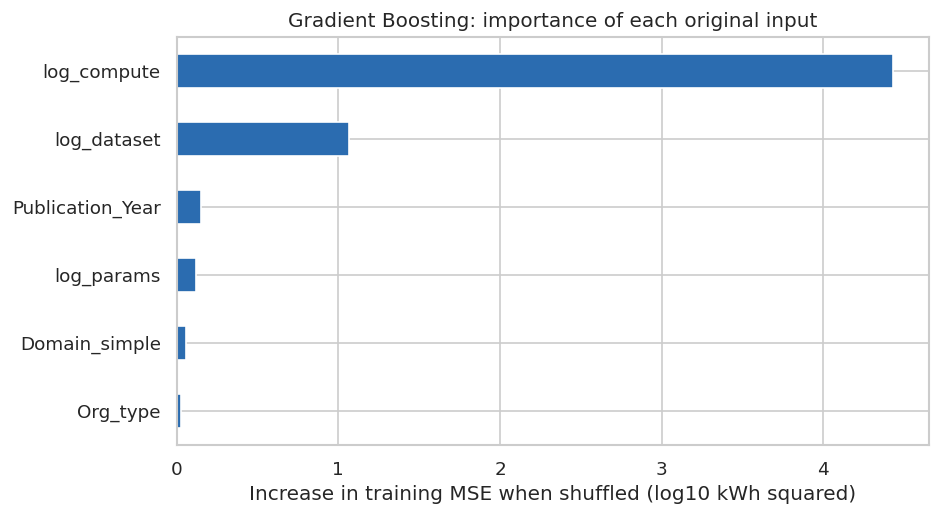

,Mean increase in training MSE
log_compute,4.430321
log_dataset,1.064413
Publication_Year,0.149410
log_params,0.120285
Domain_simple,0.055034
Org_type,0.029031


In [19]:
from sklearn.inspection import permutation_importance

# Optional interpretation of the fitted tree; training data only, not model selection.
gb_importance = permutation_importance(
    gb_search.best_estimator_, X_train, y_train,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_mean_squared_error'
)
importance = pd.Series(gb_importance.importances_mean, index=X_train.columns).sort_values()
ax = importance.plot.barh(figsize=(8, 4.5), color='#2b6cb0')
ax.set_title('Gradient Boosting: importance of each original input')
ax.set_xlabel('Increase in training MSE when shuffled (log10 kWh squared)')
plt.tight_layout()
plt.show()
importance.sort_values(ascending=False).to_frame('Mean increase in training MSE')

### Model Choice & Trade-offs

Gradient Boosting performs best on the training folds, including after tuning (**0.587** mean fold RMSE versus Ridge's **0.615**), but it also has a larger train–validation R² gap in the initial comparison (**0.129** versus **0.035** for Ridge alpha 1). The gap suggests more sensitivity to these few training examples, though it is not proof of future failure. I carry **tuned Ridge** forward into detailed evaluation because its performance is close, its coefficients are easier to explain, and an early energy-screening tool benefits from transparent assumptions. Both methods would need validation with measured energy and more diverse runs before operational use.

## Model Evaluation & Optimization

### Evaluation Overview

The two models revisited here are **ordinary Linear Regression** and **Ridge Regression**, evaluated with the same five-fold cross-validation on the 148 training models. The untouched 37-model test set is reserved for the selected, tuned Ridge model. All cross-validation errors below are measured on **log10(kWh)**; R² is dimensionless.

| Model | Training-fold CV RMSE ↓ | Training-fold CV MAE ↓ | Training-fold CV R² ↑ | Mean training-fold R² | Generalization gap |
|---|---:|---:|---:|---:|---:|
| Linear Regression (no penalty) | 0.633 | 0.448 | 0.850 | 0.889 | 0.039 |
| Ridge (alpha = 1) | 0.625 | 0.442 | 0.853 | 0.888 | 0.035 |

**RMSE** emphasizes large mistakes, especially concerning when a run is much more energy intensive than predicted. **MAE** expresses the average size of prediction errors in log units. A log10 error of 0.442 corresponds to a factor of about 2.8, although this is not the same as saying every prediction misses by that factor. **R²** describes the variation in the *derived log-energy target* explained on validation folds. These scores describe within-dataset predictive performance, not independently measured electricity savings.

After selecting Ridge and tuning it on training folds, the **held-out test** results were RMSE **0.785 log10 kWh**, MAE **0.570 log10 kWh**, and R² **0.829**. Its back-transformed test MAE was **614,122 kWh**, with a median absolute multiplicative error of **2.41×**. This is a different split from the cross-validation table, so its numbers should not be interpreted as a direct before/after comparison.

#### Are these results useful?

The model can help AI development and sustainability teams estimate the **rough scale** of training electricity needs while planning a run and decide where more precise measurement is needed. Its typical multiplicative error makes it unsuitable for exact energy budgets, official carbon accounting, penalties, or ranking individual organizations. I would trust it more for a proposed run similar to well-documented models in the data, when all planning inputs are known, and less for undisclosed, unusual, or very large future training runs. The target is itself based on estimated power draw multiplied by reported training time, so even a low test error is not proof of agreement with a physical electricity meter.

### Regularization & Overfitting

The unregularized Linear Regression and regularized Ridge use the same standardized numeric features, encoded categories, split, and folds (Step 6). Adding Ridge's L2 penalty reduces validation RMSE from **0.633 to 0.625** and shrinks the mean training-to-validation R² gap from **0.039 to 0.035**. These modest improvements suggest slightly better generalization, not evidence of a large overfitting problem in the linear baseline. In Ridge, the penalty discourages large coefficients and keeps correlated predictors from producing unstable estimates; unlike Lasso, it does not aim to set coefficients exactly to zero. The fitted Ridge coefficient chart in Step 8 shows the final associations. Because the notebook does not report a side-by-side coefficient table for ordinary Linear Regression, the exact size of coefficient shrinkage is not quantified here.

#### Hyperparameter Refinement

The previous grid search already tested Ridge alpha values around its best result: **1** produced mean CV RMSE **0.616**, **3** produced **0.615**, and **10** produced **0.639** log10 kWh (unrounded values and fold variation appear in Step 7). Alpha **3** was selected. The roughly 0.001 difference between alpha 1 and 3 is small compared with the roughly 0.10 standard deviation across folds; a narrower search would not support a meaningful improvement claim on only 148 training examples. I therefore retained the existing tuning instead of using the test set to choose more settings.

### Model Assumptions & Diagnostics

The four diagnostic panels in Step 8 show held-out predictions against actual log-energy, residuals against predicted values, a Q–Q plot, and the residual distribution. The residual-versus-predicted view shows no strong systematic curve or clear fan shape, but this small test set cannot establish constant variance conclusively. The residual distribution departs from normality (Shapiro–Wilk **p = 0.026**). There are notable misses: **IMPALA** has a residual of **−2.525 log10 kWh**, and Flan-PaLM 540B has **−1.759**; negative residual means the model overpredicted the derived target. These examples have large *prediction errors*; the notebook does not compute leverage or Cook's distance, so it does not establish that they are influential training observations.

The log transforms reduce the effect of the long-tailed input and target distributions. As discussed in Step 4, plausible high-energy training runs were retained instead of discarded merely for being large. I have not removed held-out examples based on their residuals: doing so would make the test result misleading. Remaining extreme misses and non-normal errors reduce confidence in individual forecasts and in simple normal-error uncertainty claims.

#### Before vs. After Optimization

For a like-for-like comparison, this table uses **the same training-set five-fold cross-validation**, not the held-out test set:

| Stage | Model | CV RMSE (log10 kWh) ↓ | CV MAE (log10 kWh) ↓ | CV R² ↑ |
|---|---|---:|---:|---:|
| Before regularization | Linear Regression | 0.633 | 0.448 | 0.850 |
| After regularization | Ridge, alpha = 1 | 0.625 | 0.442 | 0.853 |

All three validation measures improved a little after adding regularization, and the training-to-validation gap decreased. Further tuning from Ridge alpha 1 to alpha 3 improved CV RMSE from approximately **0.616 to 0.615** under the *GridSearchCV mean-of-fold-RMSE calculation*; this is a separate scoring aggregation from the 0.625 shown in the first table, which is the square root of mean fold MSE. We do not have matching MAE and R² values from the alpha-3 grid search, so no such values are claimed. The gain is small, and choosing the interpretable Ridge model accepts a slightly worse tuned CV RMSE than Gradient Boosting (**0.587**) in exchange for simpler explanation.

### Final Model & Impact Reflection

The final model is **Ridge, alpha 3**, fitted to log-transformed model size, training compute, and dataset size, plus publication year, domain, and organization type. Its largest positive standardized numeric coefficient belongs to training compute (**1.356**), followed by dataset size (**0.422**) and model size (**0.107**). Publication year has a negative coefficient (**−0.367**) after adjustment for the other inputs. This broadly matches the expectation that more compute is associated with more training energy, but correlated inputs, grouping choices, and incomplete reporting mean these coefficients should not be read as causal effects or reliable savings from changing one factor.

Developers, sustainability teams, managers, and funders could use these predictions when assessing proposed training runs. The main fairness concern is **unequal reliability across kinds of projects and organizations**, rather than demographic fairness for individuals: only 185 of 3,620 records have the required information, and poorly documented runs are excluded. Before operational use, collect independently measured electricity use, check errors for small versus large models and across domains where sample sizes permit, and track whether newer runs become harder to predict. Present estimates with their limitations; do not use this model alone for binding allocations, public rankings, or carbon reporting.


## Technical Summary & Workflow

### Problem and hypothesis

**Question:** To what extent can model size, training compute, and dataset size predict the electricity consumed when training an AI model? Larger models and training runs are expected to use more energy, with training compute the strongest predictor. Publication year, model domain, and organization type provide context. Training duration is relevant to energy use but is **not a model input here**: the target is calculated as aggregate training power draw (watts) × training time (hours) ÷ 1,000. Including either duration or power draw as a predictor would leak a component of the answer into the model.

### Data and preparation

The source is Epoch AI's [Data on AI Models](https://epoch.ai/data/ai-models), using the CSV downloaded on 24 September 2026 as described in Step 2. Of 3,620 recorded models, **185** have the five fields required for the target and core predictors. Two malformed numeric values were repaired, rows with missing core values were removed, and nonpositive values were excluded before logarithms were taken. Rare domain grouping was fitted inside each training fold, while organization labels were simplified; model size, compute, dataset size, and the target were transformed to base-10 logarithms because their values span many orders of magnitude. Numeric inputs were scaled and categorical inputs one-hot encoded within the fitted pipeline. The training data comprises 148 models and the untouched test set 37; model selection used five-fold cross-validation within training data only.

### Models and results

We compared a mean-value baseline, ordinary linear regression, Ridge, Lasso, Random Forest, and Gradient Boosting. Gradient Boosting had the lowest tuned cross-validation RMSE (**0.587 log10 kWh**); tuned Ridge had **0.615 log10 kWh**. Ridge with alpha = 3 was chosen for its comparable validation performance and coefficients that can be discussed with stakeholders. On the held-out test set, Ridge achieved **RMSE 0.785 log10 kWh, MAE 0.570 log10 kWh, and R² 0.829**. After conversion back to kWh, RMSE was **2,048,469 kWh** and MAE **614,122 kWh**; these large original-scale errors reflect the extreme range in training-run sizes. The median multiplicative error was **2.41×**, so even a typical prediction may be substantially above or below the derived target. These figures measure prediction of an *estimated* energy target, not independently metered electricity. The strongest positive Ridge coefficient was training compute; coefficient size describes associations, not proof that changing one input causes a proportional energy saving.

### Assumptions and boundaries

The log-scale linear relationship is a useful approximation, but the test residuals depart from normality (Shapiro–Wilk p = 0.026), and some individual predictions are far off. Power draw itself is estimated, disclosure is incomplete, and hardware efficiency, facility overhead, repeated experiments, and deployment energy are not fully captured. The sample favours publicly documented models, so accuracy for undisclosed and future frontier runs is unknown. Ridge was chosen using cross-validation; its test results come from one small split, not repeated external validation. Treat this model as a rough planning and comparison aid, not a measured energy bill or certified carbon figure.

## Executive Summary for Non-Technical Audiences

Training AI models uses electricity, but teams often do not have a clear estimate while planning a run. An early estimate can help them consider energy use alongside cost and expected benefits. This project looked at 185 publicly documented AI models to explore which information known during planning is most useful for estimating training electricity use.

I built a model that uses planned training compute, model size, dataset size, and basic context to estimate electricity use. **Training compute was the strongest signal** in the selected model. On models set aside for testing, it explained much of the difference in estimated energy use, but individual estimates could still be several times too high or too low.

Developers and sustainability teams could use the estimate to compare proposed runs and decide which ones deserve closer measurement or an efficiency review. They should verify important decisions with actual electricity measurements. The model gives a rough guide to energy use; it does not measure emissions or prove how much energy a specific change will save.

## Key Visualizations & Insights

The three figures below bring together the model comparison, held-out predictions, and the selected model's coefficients. The detailed diagnostic plots and calculations remain in the earlier workflow.

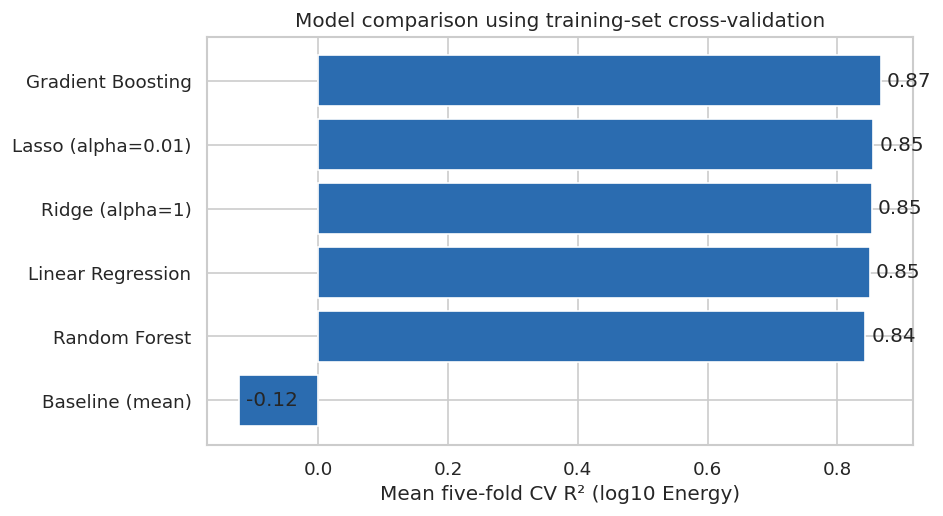

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
comparison_sorted = comparison.sort_values('CV R2 (mean)')
bars = ax.barh(comparison_sorted.index, comparison_sorted['CV R2 (mean)'], color='#2b6cb0')
ax.set_xlabel('Mean five-fold CV R² (log10 Energy)')
ax.set_title('Model comparison using training-set cross-validation')
for bar, val in zip(bars, comparison_sorted['CV R2 (mean)']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.2f}", va='center')
plt.tight_layout()
plt.show()


**Figure 1 — Comparing models.** Higher cross-validation R² means the model explained more variation across training folds. All trained models beat the simple mean-value baseline. The chart compares models during selection; it is not their final test performance.

Final Ridge test RMSE: 0.785 log10 kWh
Final Ridge test MAE: 0.570 log10 kWh
Final Ridge test R2: 0.829
Back-transformed test RMSE: 2,048,469 kWh
Back-transformed test MAE: 614,122 kWh
Median multiplicative error factor: 2.41x
Shapiro-Wilk normality test on residuals: W=0.932, p=0.026
(p > 0.05 fails to reject normality; p <= 0.05 suggests deviation from normality)

Largest absolute residuals (positive = underprediction; negative = overprediction):


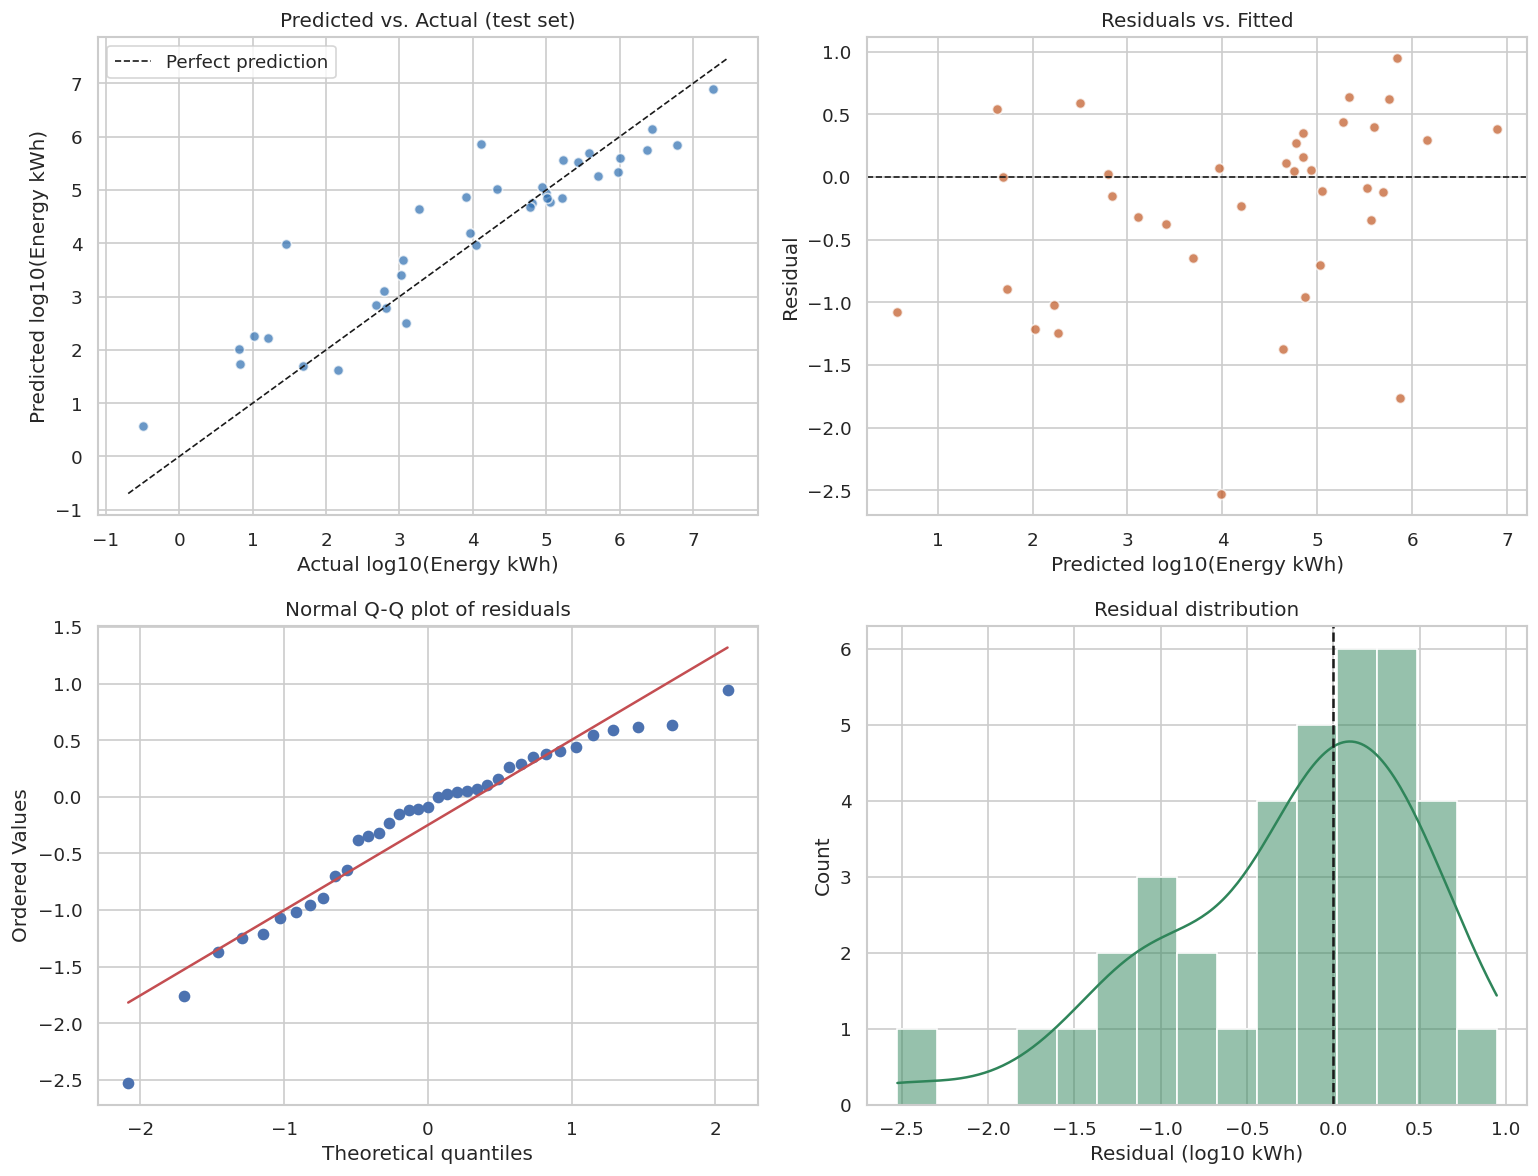

,Model,Organization,Publication_Year,Energy_kWh,residual
16,IMPALA,DeepMind,2018,28.557259,-2.525319
107,Flan-PaLM 540B,Google,2022,12887.922552,-1.759416
138,Refact-1.6B,Refact AI,2023,1842.695208,-1.373819


In [21]:
# The held-out test set is used once, after model selection and tuning are complete.
pred_test = best_ridge.predict(X_test)
residuals = y_test.to_numpy() - pred_test

tuned_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
tuned_mae = mean_absolute_error(y_test, pred_test)
tuned_r2 = r2_score(y_test, pred_test)
actual_kwh = 10 ** y_test.to_numpy()
predicted_kwh = 10 ** pred_test
rmse_kwh = np.sqrt(mean_squared_error(actual_kwh, predicted_kwh))
mae_kwh = mean_absolute_error(actual_kwh, predicted_kwh)
median_error_factor = np.median(10 ** np.abs(residuals))

print(f"Final Ridge test RMSE: {tuned_rmse:.3f} log10 kWh")
print(f"Final Ridge test MAE: {tuned_mae:.3f} log10 kWh")
print(f"Final Ridge test R2: {tuned_r2:.3f}")
print(f"Back-transformed test RMSE: {rmse_kwh:,.0f} kWh")
print(f"Back-transformed test MAE: {mae_kwh:,.0f} kWh")
print(f"Median multiplicative error factor: {median_error_factor:.2f}x")


fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Predicted vs Actual
axes[0,0].scatter(y_test, pred_test, alpha=0.7, color='#2b6cb0', edgecolor='white')
lims = [min(y_test.min(), pred_test.min()) - 0.2, max(y_test.max(), pred_test.max()) + 0.2]
axes[0,0].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
axes[0,0].set_xlabel('Actual log10(Energy kWh)')
axes[0,0].set_ylabel('Predicted log10(Energy kWh)')
axes[0,0].set_title('Predicted vs. Actual (test set)')
axes[0,0].legend()

# 2. Residuals vs Fitted (homoscedasticity / linearity)
axes[0,1].scatter(pred_test, residuals, alpha=0.7, color='#c05621', edgecolor='white')
axes[0,1].axhline(0, color='k', linestyle='--', linewidth=1)
axes[0,1].set_xlabel('Predicted log10(Energy kWh)')
axes[0,1].set_ylabel('Residual')
axes[0,1].set_title('Residuals vs. Fitted')

# 3. QQ-plot (normality of residuals)
stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Normal Q-Q plot of residuals')

# 4. Residual distribution
sns.histplot(residuals, bins=15, kde=True, ax=axes[1,1], color='#2f855a')
axes[1,1].axvline(0, color='k', linestyle='--')
axes[1,1].set_title('Residual distribution')
axes[1,1].set_xlabel('Residual (log10 kWh)')

plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk normality test on residuals: W={shapiro_stat:.3f}, p={shapiro_p:.3f}")
print(f"(p > 0.05 fails to reject normality; p <= 0.05 suggests deviation from normality)")

worst_order = np.argsort(np.abs(residuals))[::-1][:3]
worst = model_df.loc[X_test.iloc[worst_order].index, ['Model','Organization','Publication_Year','Energy_kWh']].copy()
worst['residual'] = residuals[worst_order]
print("\nLargest absolute residuals (positive = underprediction; negative = overprediction):")
worst


**Figure 2 — Predictions and errors.** In the top-left plot, points closer to the diagonal indicate better predictions on 37 held-out models. The other panels show where predictions were wrong; some large misses remain, so a single estimate should not be treated as an exact energy measurement. The axes use log10(kWh), where a one-unit error means a tenfold difference in kWh.

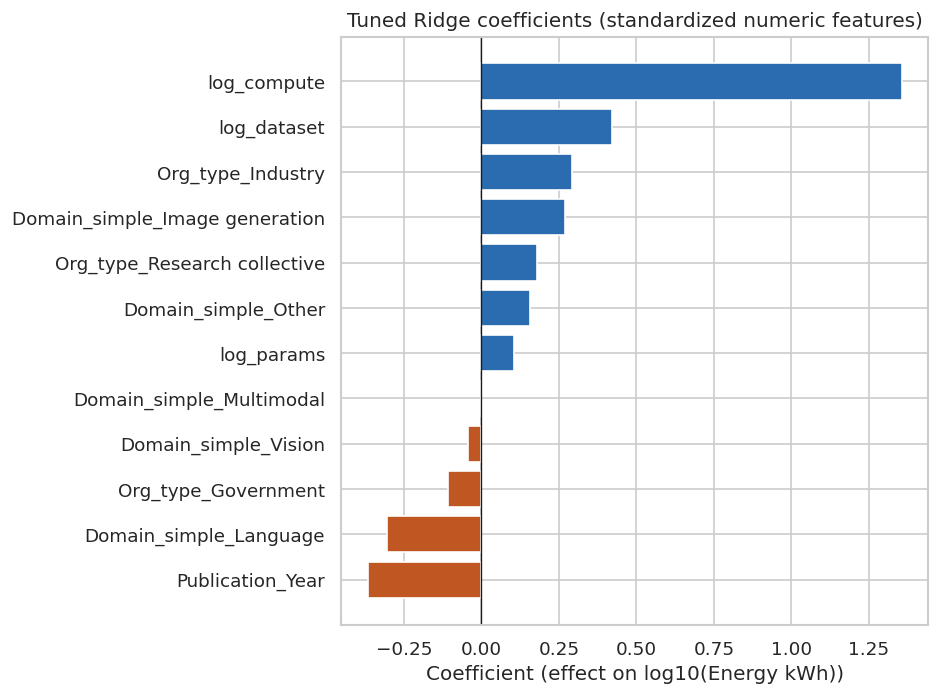

,0
log_compute,1.356118
log_dataset,0.422259
Org_type_Industry,0.290958
Domain_simple_Image generation,0.268732
Org_type_Research collective,0.178289
Domain_simple_Other,0.158148
log_params,0.106579
Domain_simple_Multimodal,-0.001717
Domain_simple_Vision,-0.042512
Org_type_Government,-0.106838


In [22]:
ridge_model = best_ridge.named_steps['model']
feature_names = (NUM_FEATURES +
                  list(best_ridge.named_steps['pre'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(CAT_FEATURES)))
coefs = pd.Series(ridge_model.coef_, index=feature_names).sort_values()

plt.figure(figsize=(8, 6))
colors = ['#c05621' if c < 0 else '#2b6cb0' for c in coefs]
plt.barh(coefs.index, coefs.values, color=colors)
plt.axvline(0, color='k', linewidth=0.8)
plt.title('Tuned Ridge coefficients (standardized numeric features)')
plt.xlabel('Coefficient (effect on log10(Energy kWh))')
plt.tight_layout()
plt.show()

coefs.sort_values(ascending=False)


**Figure 3 — What the Ridge model uses.** Training compute has the strongest positive coefficient among the measured inputs. Numeric features were scaled before fitting, while category indicators use reference groups; compare coefficient signs and sizes cautiously. These are associations in this sample, not causal energy savings.

## How This Model Could Be Used

- **AI developers and research teams:** include an estimated energy range in the planning checklist for proposed training runs; compare alternatives before allocating compute. Show inputs and the warning that results are approximate.
- **Sustainability teams:** use a short internal report to flag high-energy plans for closer review and collect power-meter readings wherever possible. Report measured and estimated numbers separately.
- **Managers and funders:** use the estimate to ask whether an expensive run is justified and whether an energy measurement plan is in place; do not set binding budgets from the estimate alone.
- **Before any operational use:** gather more recent runs with independently measured energy, test the model across small and large models and different hardware, get feedback from users, and check whether predictions remain reliable as training technology changes. Retrain only after checking the new data and validation results.

## Limitations, Fairness & Ethical Considerations

- **What it does not measure:** the outcome is an estimate from power draw and training time, not a direct meter reading. It covers a reported training run, not all experiments, facility overhead, model use after training, or carbon emissions. Predictions should be labelled *estimated training kWh*.
- **Uneven coverage:** only 185 of 3,620 models have the required fields. Labs that disclose little information, and unusual or future training runs, may be poorly represented. If the model performs worse for certain model sizes, domains, organization types, or years, comparisons across those groups could be misleading. Check MAE and systematic over- or underestimation by group when enough examples are available.
- **Potential misuse:** an inaccurate estimate might lead teams to approve a run with higher energy use than expected or unfairly criticize a lab that reports limited data. Avoid public rankings, penalties, or exact carbon claims based on these predictions. The immediate beneficiaries are developers and sustainability teams with enough planning data; less transparent organizations and smaller groups with sparse records may receive less reliable estimates.
- **Monitoring:** after any pilot deployment, compare estimates with new, independently measured energy data; track overall error and error by model size and available groups, record missing inputs, and review performance periodically. Pause operational reliance if the errors increase. I would accept slightly lower average accuracy for a more understandable model with fewer consistently poor predictions for any tested group. Fairness here concerns the reliability of comparisons between kinds of AI projects, not demographic fairness for individuals.